# UIDD hyperparameter sensitivity plots

这个 notebook 只读取已经保存的结果文件，不重新训练、不重新计算误差。主要数据源：

- `outputs/uidd_sensitivity/analysis/metrics_by_seed.csv`
- `outputs/uidd_sensitivity/analysis/metrics_summary.csv`

常用微调入口在下一个单元：可以改字体、图片大小、是否显示 seed 点、是否显示标准差误差棒、是否排除某些 seed，以及每个指标的 y 轴范围。

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Let matplotlib render notebook figures sharply.
%config InlineBackend.figure_format = "retina"

# ---------------------------------------------------------------------
# 可微调参数
# ---------------------------------------------------------------------
PLOT_STYLE = {
    "figsize": (9.4, 6.6),
    "dpi": 300,
    "font_size": 12,
    "title_size": 17,
    "label_size": 12,
    "tick_size": 11,
    "line_width": 1.8,
    "marker_size": 5.2,
    "capsize": 3.5,
    "seed_marker_size": 22,
    "seed_alpha": 0.45,
    "seed_jitter": 0.05,  # fixed horizontal offset range for per-seed points; set 0 to disable
    "show_errorbars": True,
    "show_seed_points": True,
    "show_baseline_line": True,
    "yscale": "linear",  # 可改成 "log"
    "x_rotation": 0,
    "grid_alpha": 0.25,
    "subplot_wspace": 0.35,
    "subplot_hspace": 0.55,
    "subplot_top": 0.88,
    "save_format": "pdf",
}

# 如果想观察去掉异常 seed 后的趋势，例如 seed=12：改成 [12] 后重新运行后续单元。
EXCLUDE_SEEDS = []

# 手动限制某些指标 y 轴范围；None 表示自动。
YLIMS = {
    "drift": None,
    "gradV": None,
    "MgradV": None,
    "WgradV": None,
    # 例子："gradV": (0.0, 0.12)
}

# 每个 factor 的显示顺序。可以按论文图需要自由调整。
LEVEL_ORDER = {
    "network": ["small", "baseline", "wide", "deep"],
    "learning_rate": ["5e-4", "baseline", "2e-3"],
    "batch_size": ["25000", "50000", "baseline", "200000"],
    "num_epochs": ["1000", "2000", "3000", "5000"],
}

# x 轴标签也可以在这里改。内部仍用 baseline 定位，图上显示为对应参数值。
LABEL_OVERRIDES = {
    "5e-4": "5e-4",
    "2e-3": "2e-3",
    "25000": "25k",
    "50000": "50k",
    "200000": "200k",
    "1000": "1000",
    "2000": "2000",
    "3000": "3000",
    "5000": "5000",
}

FACTOR_LABEL_OVERRIDES = {
    "network": {
        "small": "V[32,16]\nH[16,8]",
        "baseline": "V[64,32]\nH[32,16]",
        "wide": "V[128,64]\nH[64,32]",
        "deep": "V[64,64,32]\nH[32,32,16]",
    },
    "learning_rate": {
        "5e-4": "5e-4",
        "baseline": "1e-3",
        "2e-3": "2e-3",
    },
    "batch_size": {
        "25000": "25k",
        "50000": "50k",
        "baseline": "100k",
        "200000": "200k",
    },
}

METRICS = ["drift", "gradV", "MgradV", "WgradV"]
METRIC_LABELS = {
    "drift": "Drift error",
    "gradV": r"$\nabla V$ error",
    "MgradV": r"$M\nabla V$ error",
    "WgradV": r"$W\nabla V$ error",
}

FACTOR_TITLES = {
    "network": "Network size",
    "learning_rate": "Learning rate",
    "batch_size": "Batch size",
    "num_epochs": "Total epochs",
}

# Colorblind-friendly palette: blue, orange, purple, dark gray.
# Avoids using red and green together.
COLORS = {
    "drift": "#0072B2",
    "gradV": "#E69F00",
    "MgradV": "#CC79A7",
    "WgradV": "#4D4D4D",
}

mpl.rcParams.update({
    "font.size": PLOT_STYLE["font_size"],
    "axes.titlesize": PLOT_STYLE["title_size"],
    "axes.labelsize": PLOT_STYLE["label_size"],
    "xtick.labelsize": PLOT_STYLE["tick_size"],
    "ytick.labelsize": PLOT_STYLE["tick_size"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": PLOT_STYLE["dpi"],
})

In [2]:
# ---------------------------------------------------------------------
# 读取已保存数据
# ---------------------------------------------------------------------
CANDIDATES = [
    Path("outputs/uidd_sensitivity/analysis"),
    Path.cwd() / "outputs/uidd_sensitivity/analysis",
    Path.cwd() / "examples/nonlinear_case/outputs/uidd_sensitivity/analysis",
    Path("/home/aiqing/nfs/UIDD-jax/examples/nonlinear_case/outputs/uidd_sensitivity/analysis"),
]

ANALYSIS_DIR = next((p.resolve() for p in CANDIDATES if (p / "metrics_summary.csv").exists()), None)
if ANALYSIS_DIR is None:
    raise FileNotFoundError("Cannot find outputs/uidd_sensitivity/analysis/metrics_summary.csv")

FIG_DIR = ANALYSIS_DIR / "replots"
FIG_DIR.mkdir(parents=True, exist_ok=True)

summary_saved = pd.read_csv(ANALYSIS_DIR / "metrics_summary.csv")
by_seed_saved = pd.read_csv(ANALYSIS_DIR / "metrics_by_seed.csv")

for df in (summary_saved, by_seed_saved):
    df["level"] = df["level"].astype(str)
    df["run_id"] = df["run_id"].astype(str)
    df["factor"] = df["factor"].astype(str)

print(f"analysis dir: {ANALYSIS_DIR}")
print(f"summary rows: {len(summary_saved)}")
print(f"per-seed rows: {len(by_seed_saved)}")
summary_saved.head()

analysis dir: /mnt/nfs/homes/aiqing/UIDD-jax/examples/nonlinear_case/outputs/uidd_sensitivity/analysis
summary rows: 13
per-seed rows: 65


,run_id,factor,level,n,source_run,checkpoint,potential_units,hamiltonian_units,learning_rate,batch_size,num_epochs,drift_mean,drift_std,gradV_mean,gradV_std,MgradV_mean,MgradV_std,WgradV_mean,WgradV_std
0,baseline,baseline,3000,5,epochs_5000,model_epoch_03000.eqx,"[64,32]","[32,16]",0.001,100000,3000,0.048280,0.000590,0.044357,0.003451,0.039320,0.004222,0.064645,0.001075
1,batch_50000,batch_size,50000,5,batch_50000,model.eqx,"[64,32]","[32,16]",0.001,50000,3000,0.048629,0.002293,0.042975,0.003025,0.037867,0.002246,0.064405,0.005027
2,batch_25000,batch_size,25000,5,batch_25000,model.eqx,"[64,32]","[32,16]",0.001,25000,3000,0.052206,0.021563,0.138618,0.192375,0.134511,0.196385,0.170531,0.235957
3,batch_200000,batch_size,200000,5,batch_200000,model.eqx,"[64,32]","[32,16]",0.001,200000,3000,0.053134,0.001580,0.044079,0.002190,0.041328,0.001409,0.074182,0.002808
4,lr_2e-3,learning_rate,2e-3,5,lr_2e-3,model.eqx,"[64,32]","[32,16]",0.002,100000,3000,0.048892,0.000367,0.042456,0.001365,0.037914,0.001537,0.066298,0.001054


In [3]:
# ---------------------------------------------------------------------
# 绘图辅助函数
# ---------------------------------------------------------------------
def aggregate_seed_metrics(seed_df: pd.DataFrame) -> pd.DataFrame:
    """Recompute mean/std from metrics_by_seed, useful after excluding seeds."""
    meta_cols = [
        "run_id", "factor", "level", "source_run", "checkpoint", "potential_units",
        "hamiltonian_units", "learning_rate", "batch_size", "num_epochs",
    ]
    rows = []
    for run_id, group in seed_df.groupby("run_id", sort=False):
        row = {col: group.iloc[0][col] for col in meta_cols if col in group.columns}
        row["n"] = int(len(group))
        for metric in METRICS:
            values = group[metric].astype(float)
            row[f"{metric}_mean"] = float(values.mean())
            row[f"{metric}_std"] = float(values.std(ddof=0))
        rows.append(row)
    out = pd.DataFrame(rows)
    out["level"] = out["level"].astype(str)
    return out


def build_plot_tables(exclude_seeds=None):
    exclude_seeds = set(exclude_seeds or [])
    seed_df = by_seed_saved.copy()
    if exclude_seeds:
        seed_df = seed_df[~seed_df["seed"].isin(exclude_seeds)].copy()
    summary_df = aggregate_seed_metrics(seed_df)
    return seed_df, summary_df


by_seed, summary = build_plot_tables(EXCLUDE_SEEDS)


def _with_baseline(df: pd.DataFrame, factor: str) -> pd.DataFrame:
    rows = df[df["factor"] == factor].copy()
    if factor != "num_epochs":
        base = df[df["run_id"] == "baseline"].copy()
        base["factor"] = factor
        base["level"] = "baseline"
        rows = pd.concat([rows, base], ignore_index=True)
    rows["level"] = rows["level"].astype(str)
    return rows


def _plot_label(factor: str, level: str) -> str:
    level = str(level)
    return FACTOR_LABEL_OVERRIDES.get(factor, {}).get(level, LABEL_OVERRIDES.get(level, level))


def _ordered_factor_rows(df: pd.DataFrame, factor: str) -> pd.DataFrame:
    rows = _with_baseline(df, factor)
    order = LEVEL_ORDER.get(factor, list(rows["level"]))
    order_index = {str(level): i for i, level in enumerate(order)}
    rows["_order"] = rows["level"].map(order_index).fillna(999).astype(int)
    rows = rows.sort_values(["_order", "level"]).drop(columns="_order").reset_index(drop=True)
    rows["plot_label"] = rows["level"].map(lambda level: _plot_label(factor, level))
    return rows


def _factor_seed_rows(seed_df: pd.DataFrame, factor: str) -> pd.DataFrame:
    rows = _with_baseline(seed_df, factor)
    rows["plot_label"] = rows["level"].map(lambda level: _plot_label(factor, level))
    return rows


def plot_factor(
    factor: str,
    metrics=METRICS,
    seed_df: pd.DataFrame | None = None,
    summary_df: pd.DataFrame | None = None,
    style: dict | None = None,
    ylims: dict | None = None,
    save: bool = False,
    filename: str | None = None,
):
    """Plot one factor as a 2x2 panel: mean +/- std, optionally with per-seed points."""
    style = {**PLOT_STYLE, **(style or {})}
    ylims = {**YLIMS, **(ylims or {})}
    seed_df = by_seed if seed_df is None else seed_df
    summary_df = summary if summary_df is None else summary_df

    rows = _ordered_factor_rows(summary_df, factor)
    raw = _factor_seed_rows(seed_df, factor)

    x = np.arange(len(rows))
    labels = rows["plot_label"].tolist()
    fig, axes = plt.subplots(2, 2, figsize=style["figsize"], dpi=style["dpi"])
    fig.subplots_adjust(wspace=style["subplot_wspace"], hspace=style["subplot_hspace"], top=style["subplot_top"])
    axes = axes.ravel()

    baseline = summary_df[summary_df["run_id"] == "baseline"].iloc[0]
    seed_values = sorted(int(seed) for seed in seed_df["seed"].unique())
    if len(seed_values) > 1 and style["seed_jitter"] > 0:
        offsets = np.linspace(-style["seed_jitter"], style["seed_jitter"], len(seed_values))
    else:
        offsets = np.zeros(len(seed_values))
    seed_offsets = dict(zip(seed_values, offsets))

    for ax, metric in zip(axes, metrics):
        color = COLORS.get(metric, "#333333")
        means = rows[f"{metric}_mean"].astype(float).to_numpy()
        stds = rows[f"{metric}_std"].astype(float).to_numpy()

        if style["show_errorbars"]:
            ax.errorbar(
                x, means, yerr=stds,
                fmt="o-", color=color, lw=style["line_width"], ms=style["marker_size"],
                capsize=style["capsize"], elinewidth=style["line_width"] * 0.8,
                label="mean +/- std",
            )
        else:
            ax.plot(x, means, "o-", color=color, lw=style["line_width"], ms=style["marker_size"], label="mean")

        if style["show_seed_points"]:
            for xi, level in enumerate(rows["level"]):
                subset = raw.loc[raw["level"] == level, ["seed", metric]].copy()
                if len(subset) == 0:
                    continue
                subset["seed"] = subset["seed"].astype(int)
                subset = subset.sort_values("seed")
                values = subset[metric].astype(float).to_numpy()
                x_seed = np.array([xi + seed_offsets.get(int(seed), 0.0) for seed in subset["seed"]])
                ax.scatter(
                    x_seed,
                    values,
                    s=style["seed_marker_size"],
                    color=color,
                    alpha=style["seed_alpha"],
                    edgecolor="white",
                    linewidth=0.35,
                    zorder=3,
                )

        if style["show_baseline_line"] and factor != "baseline":
            ax.axhline(float(baseline[f"{metric}_mean"]), color="#666666", lw=0.9, ls="--", alpha=0.65)

        ax.set_title(METRIC_LABELS.get(metric, metric), pad=10, fontsize=style["title_size"])
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=style["x_rotation"], ha="center")
        ax.set_ylabel("relative error")
        ax.set_yscale(style["yscale"])
        if ylims.get(metric) is not None:
            ax.set_ylim(*ylims[metric])
        ax.grid(axis="y", alpha=style["grid_alpha"])

    fig.suptitle(FACTOR_TITLES.get(factor, factor), y=0.98, fontsize=style["title_size"] + 3, fontweight="semibold")

    if save:
        filename = filename or f"{factor}_metrics_replot.{style['save_format']}"
        out = FIG_DIR / filename
        fig.savefig(out, bbox_inches="tight", dpi=style["dpi"])
        print(f"saved: {out}")
    return fig, axes


def plot_all_factors(save=False):
    figs = {}
    for factor in ["network", "learning_rate", "batch_size", "num_epochs"]:
        figs[factor] = plot_factor(factor, save=save)
        display(figs[factor][0])
        plt.close(figs[factor][0])
    return figs

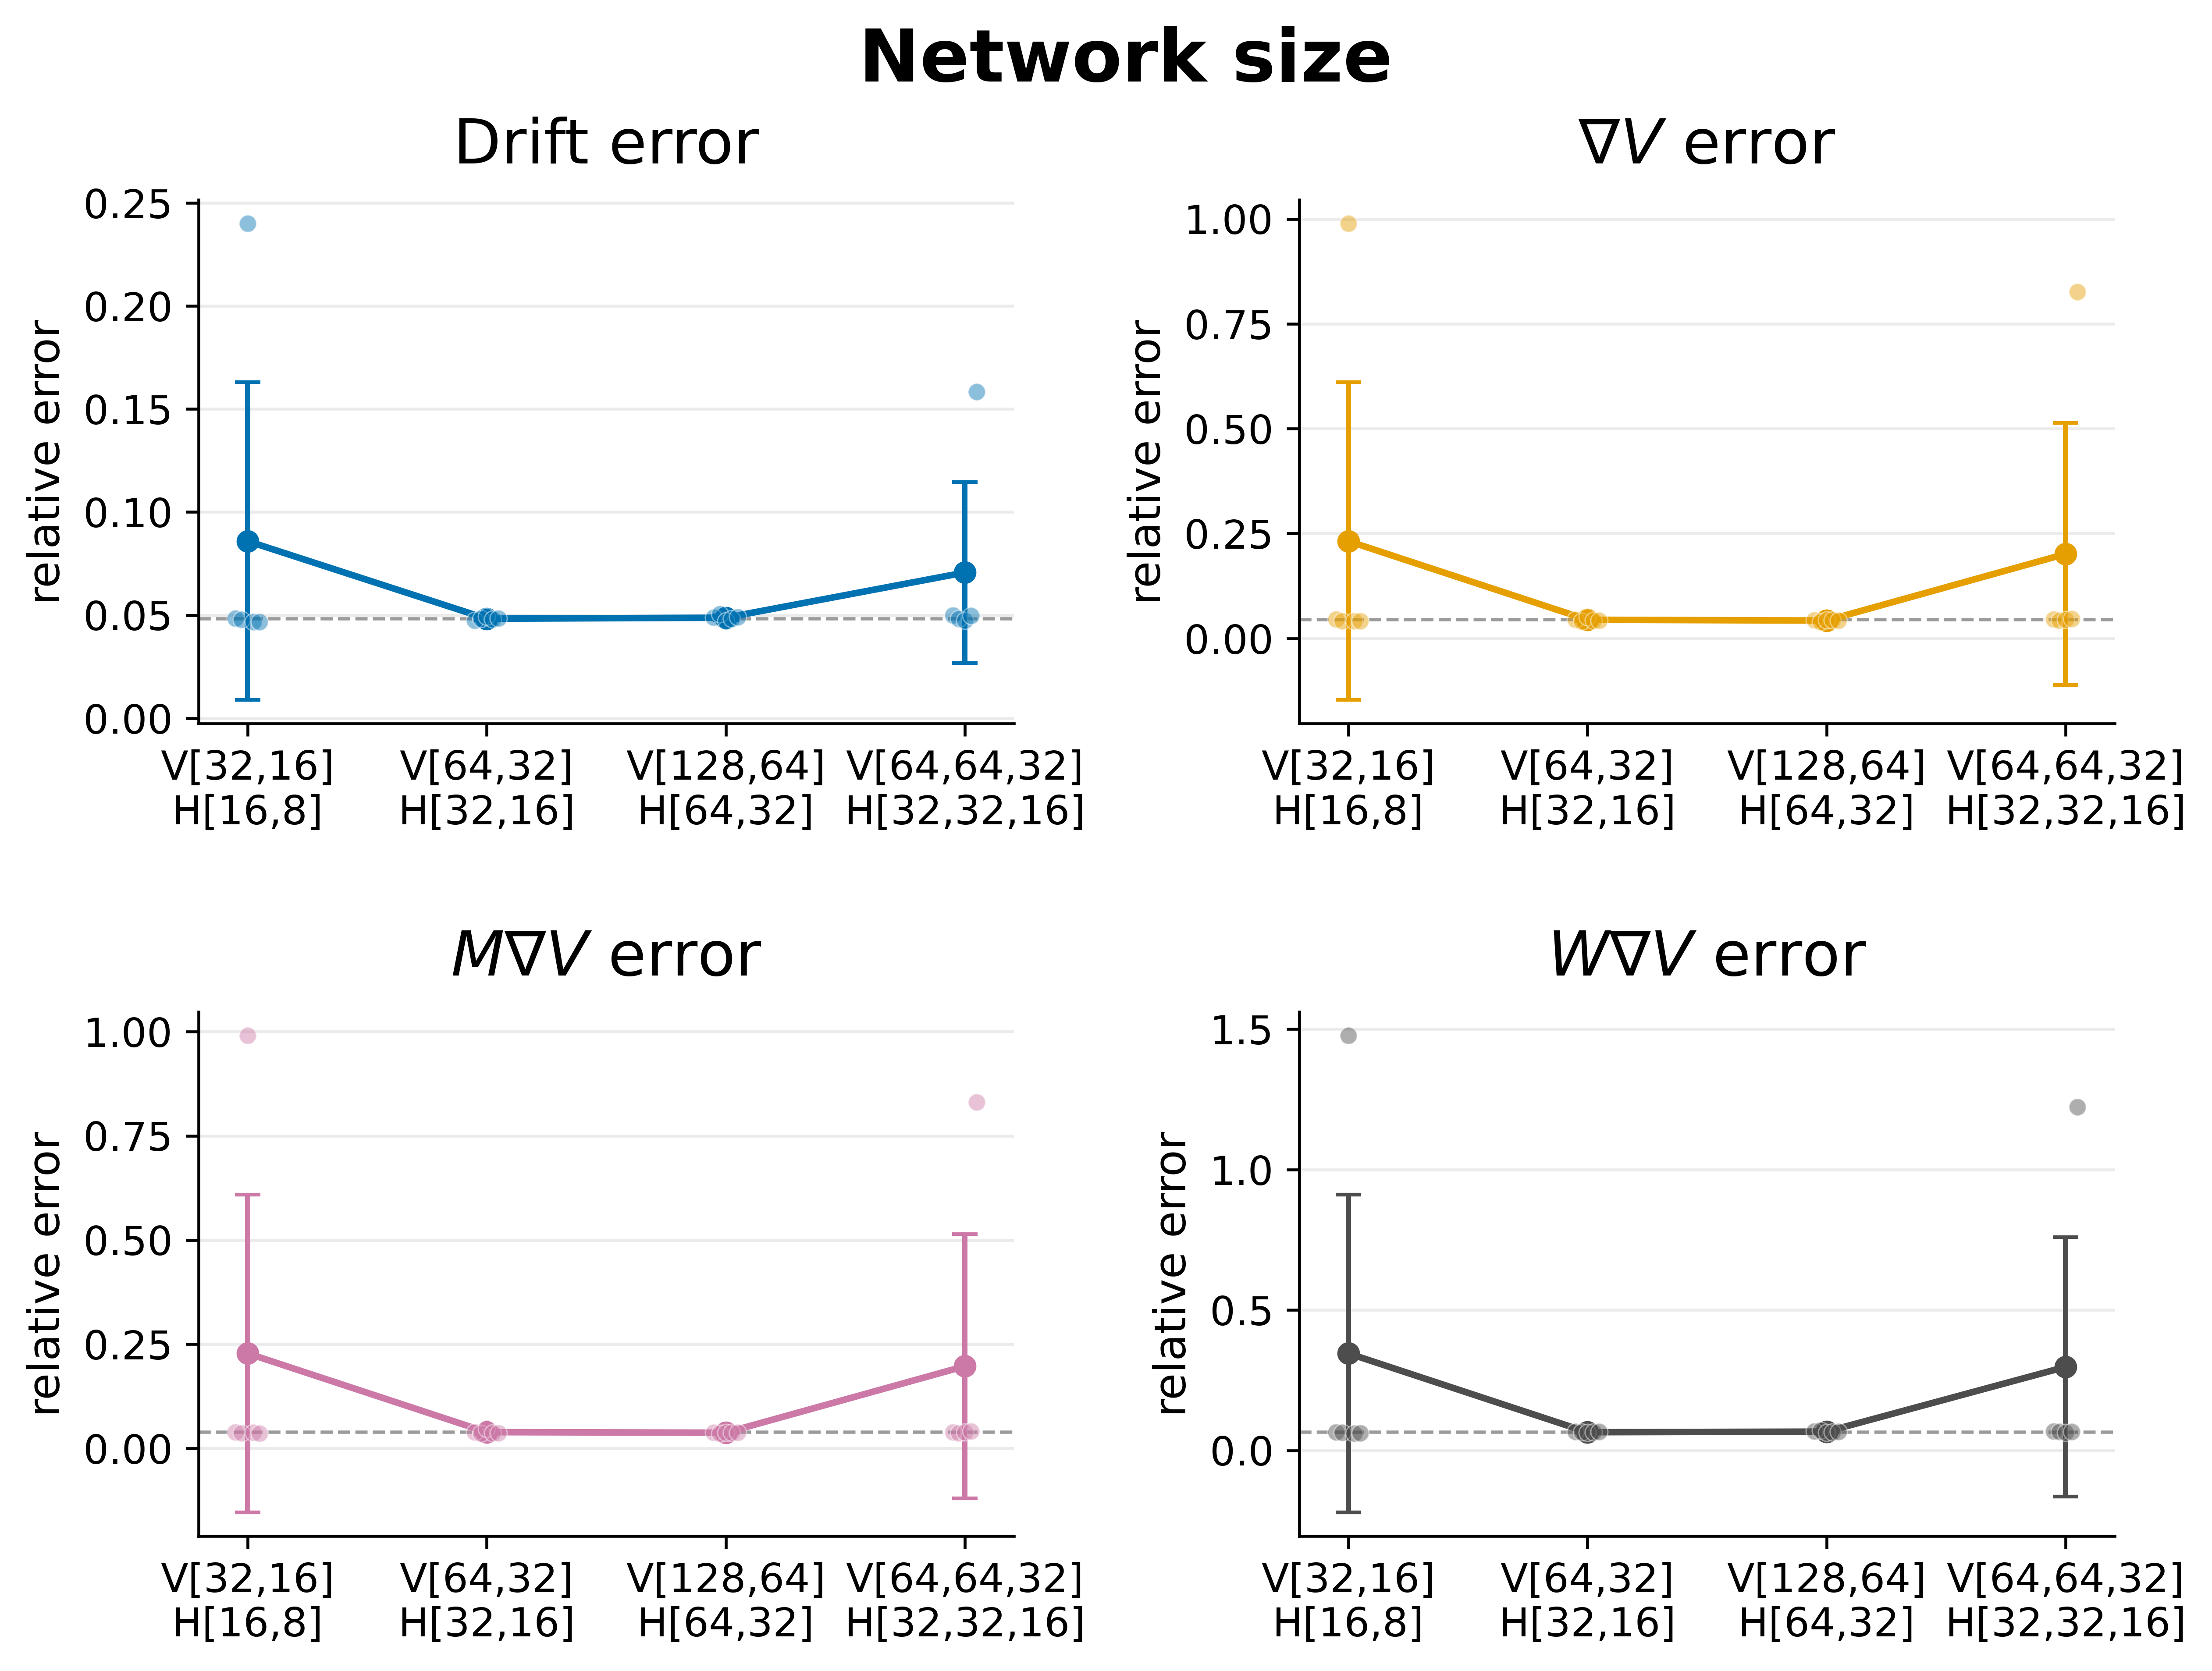

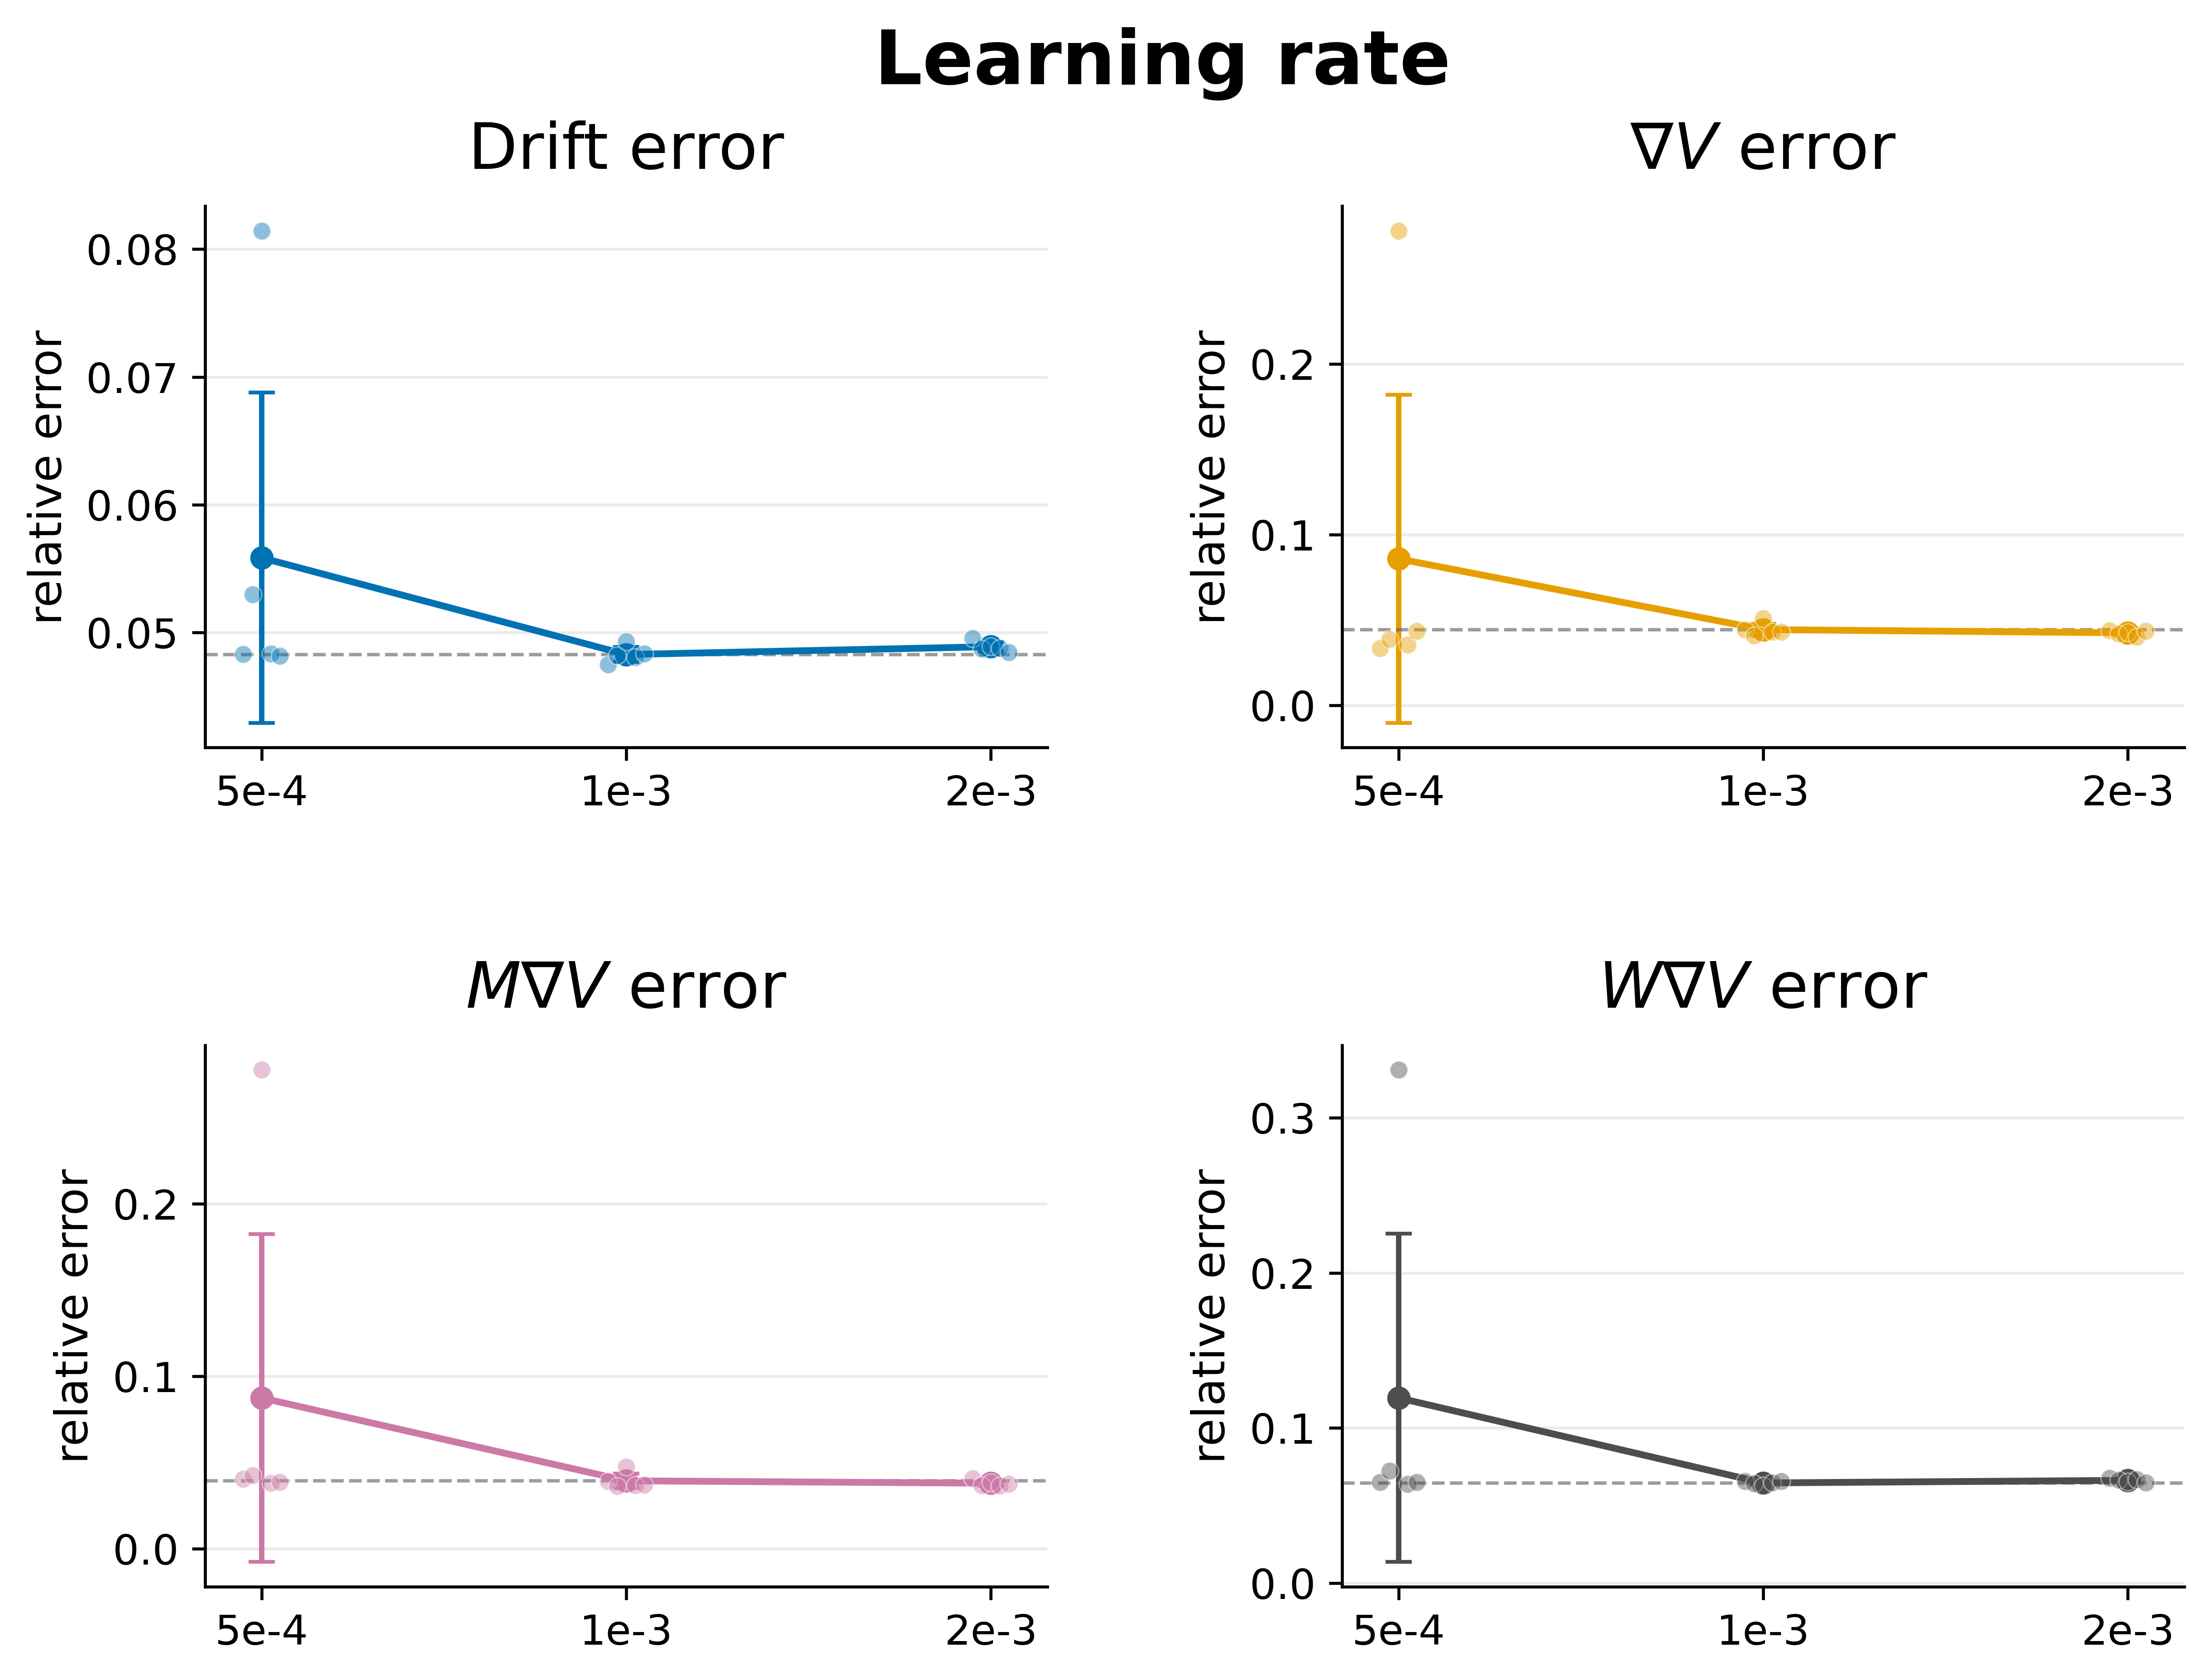

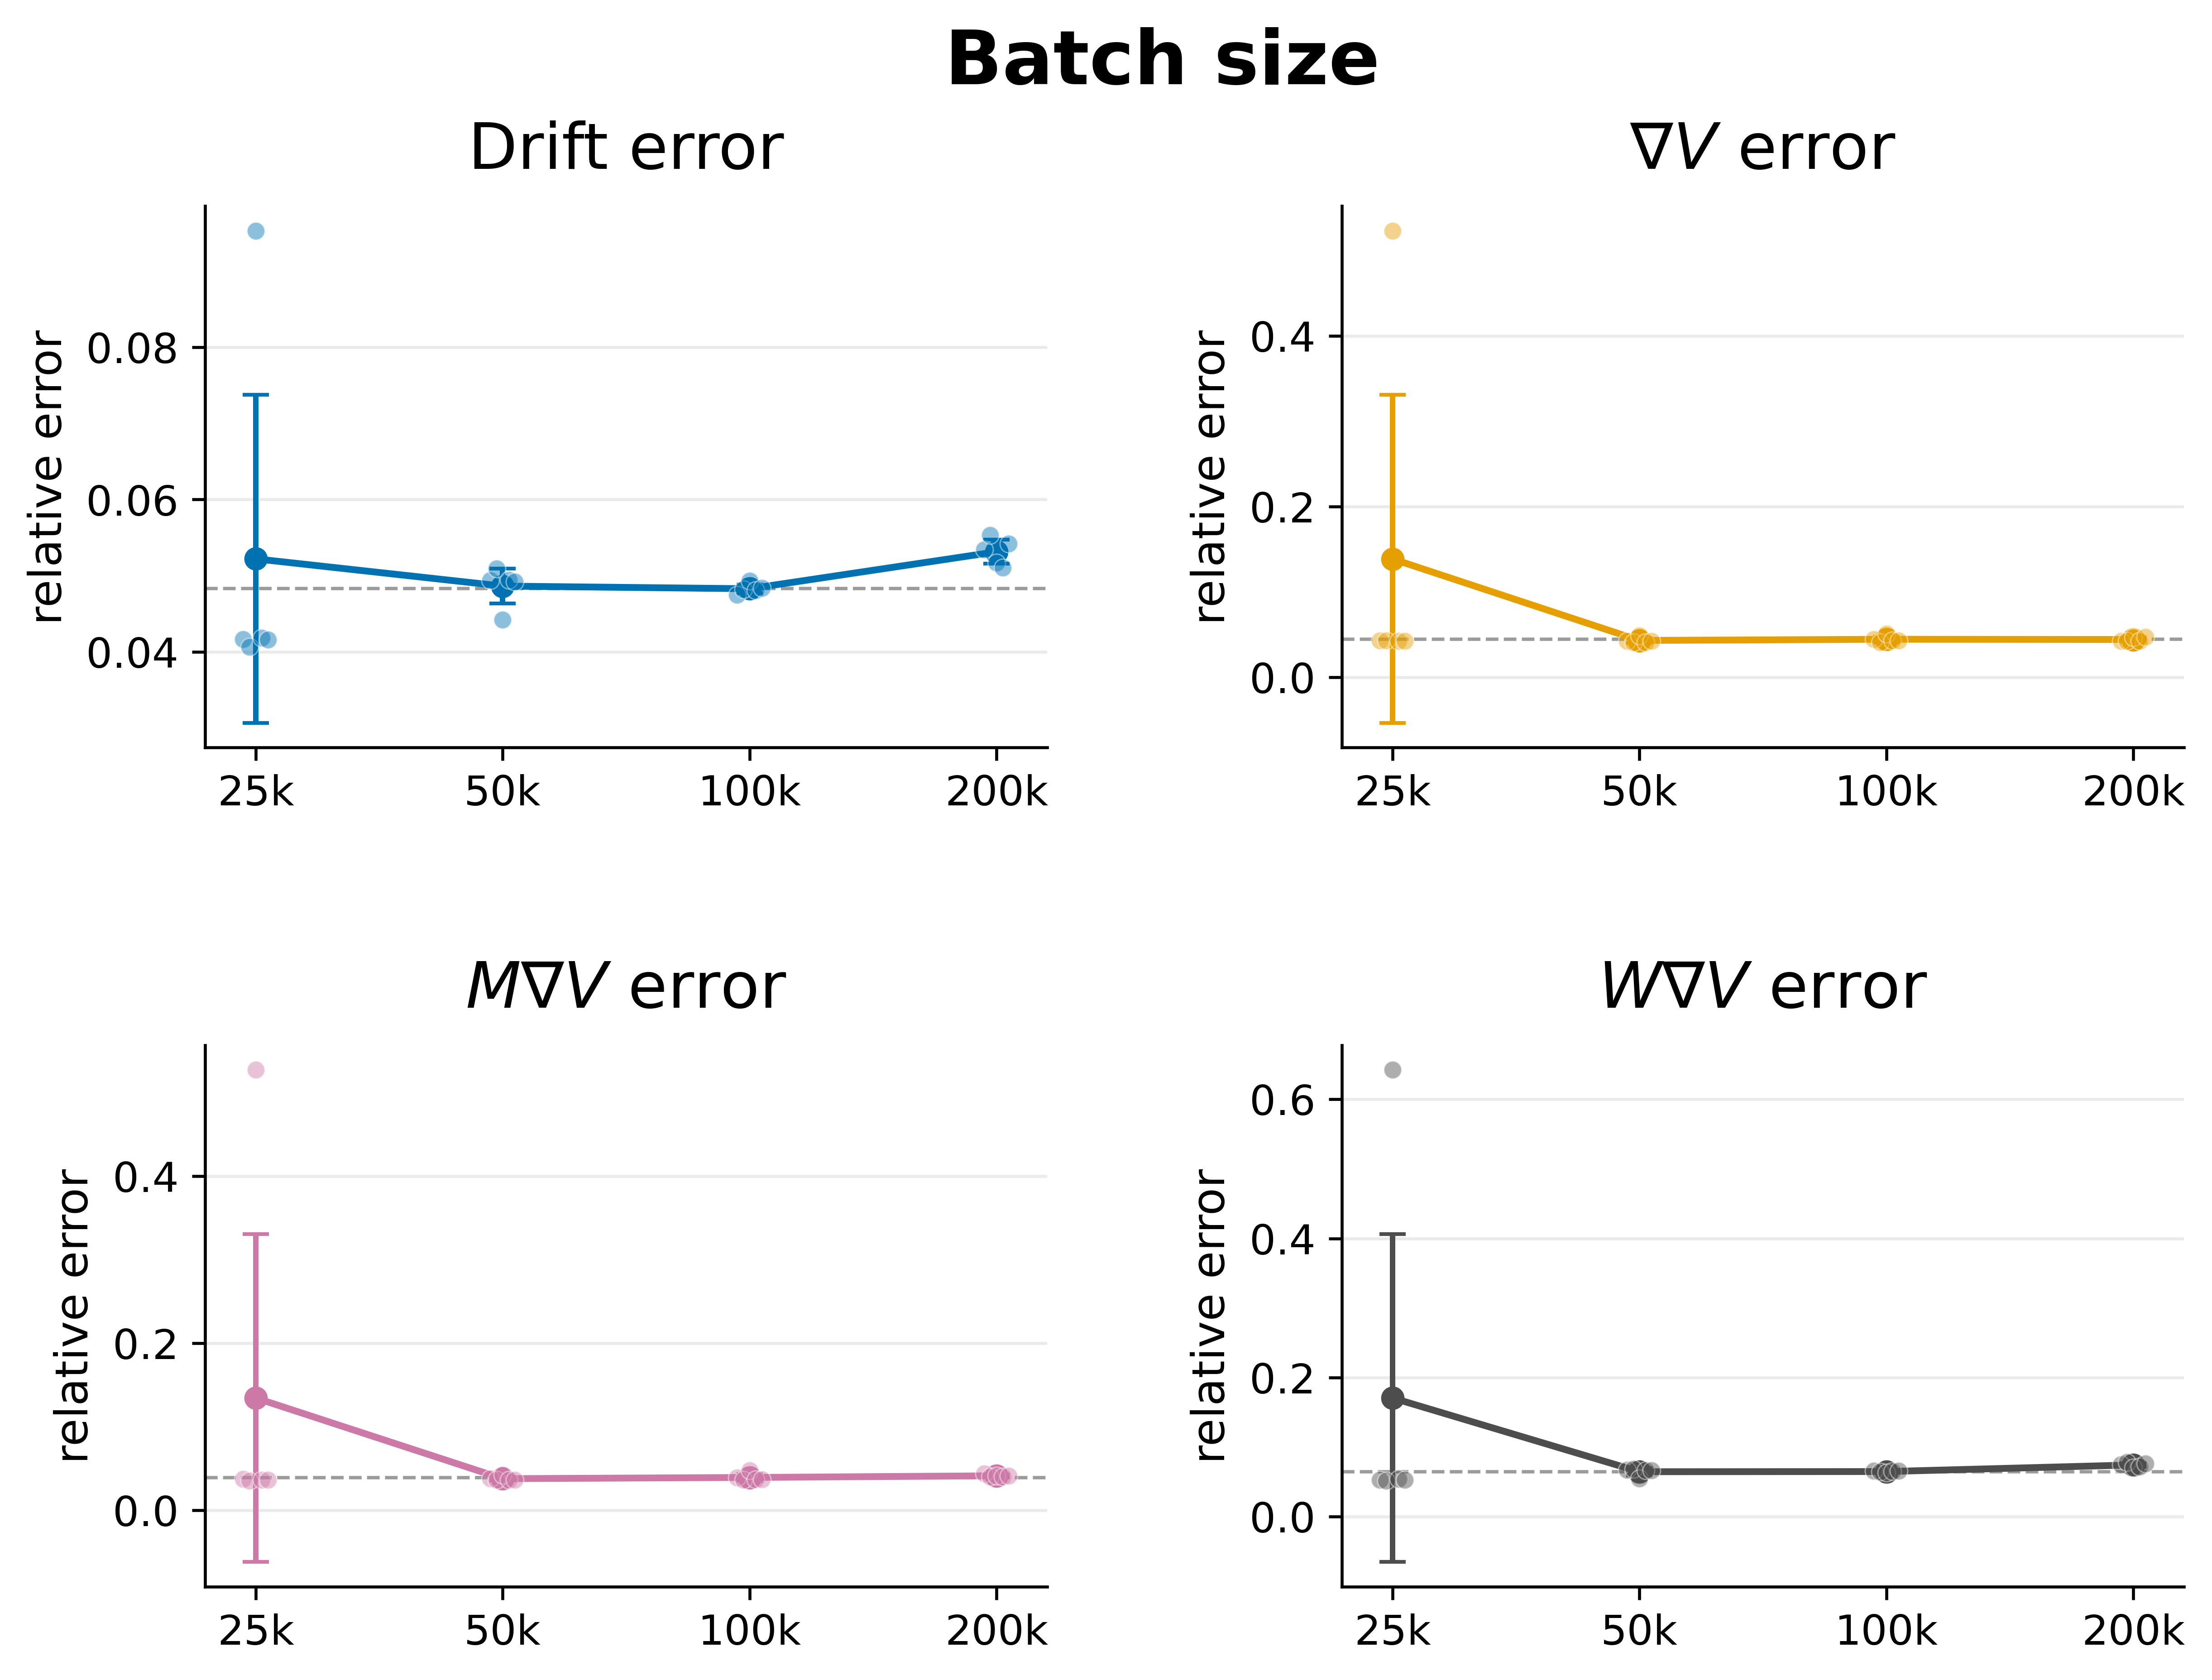

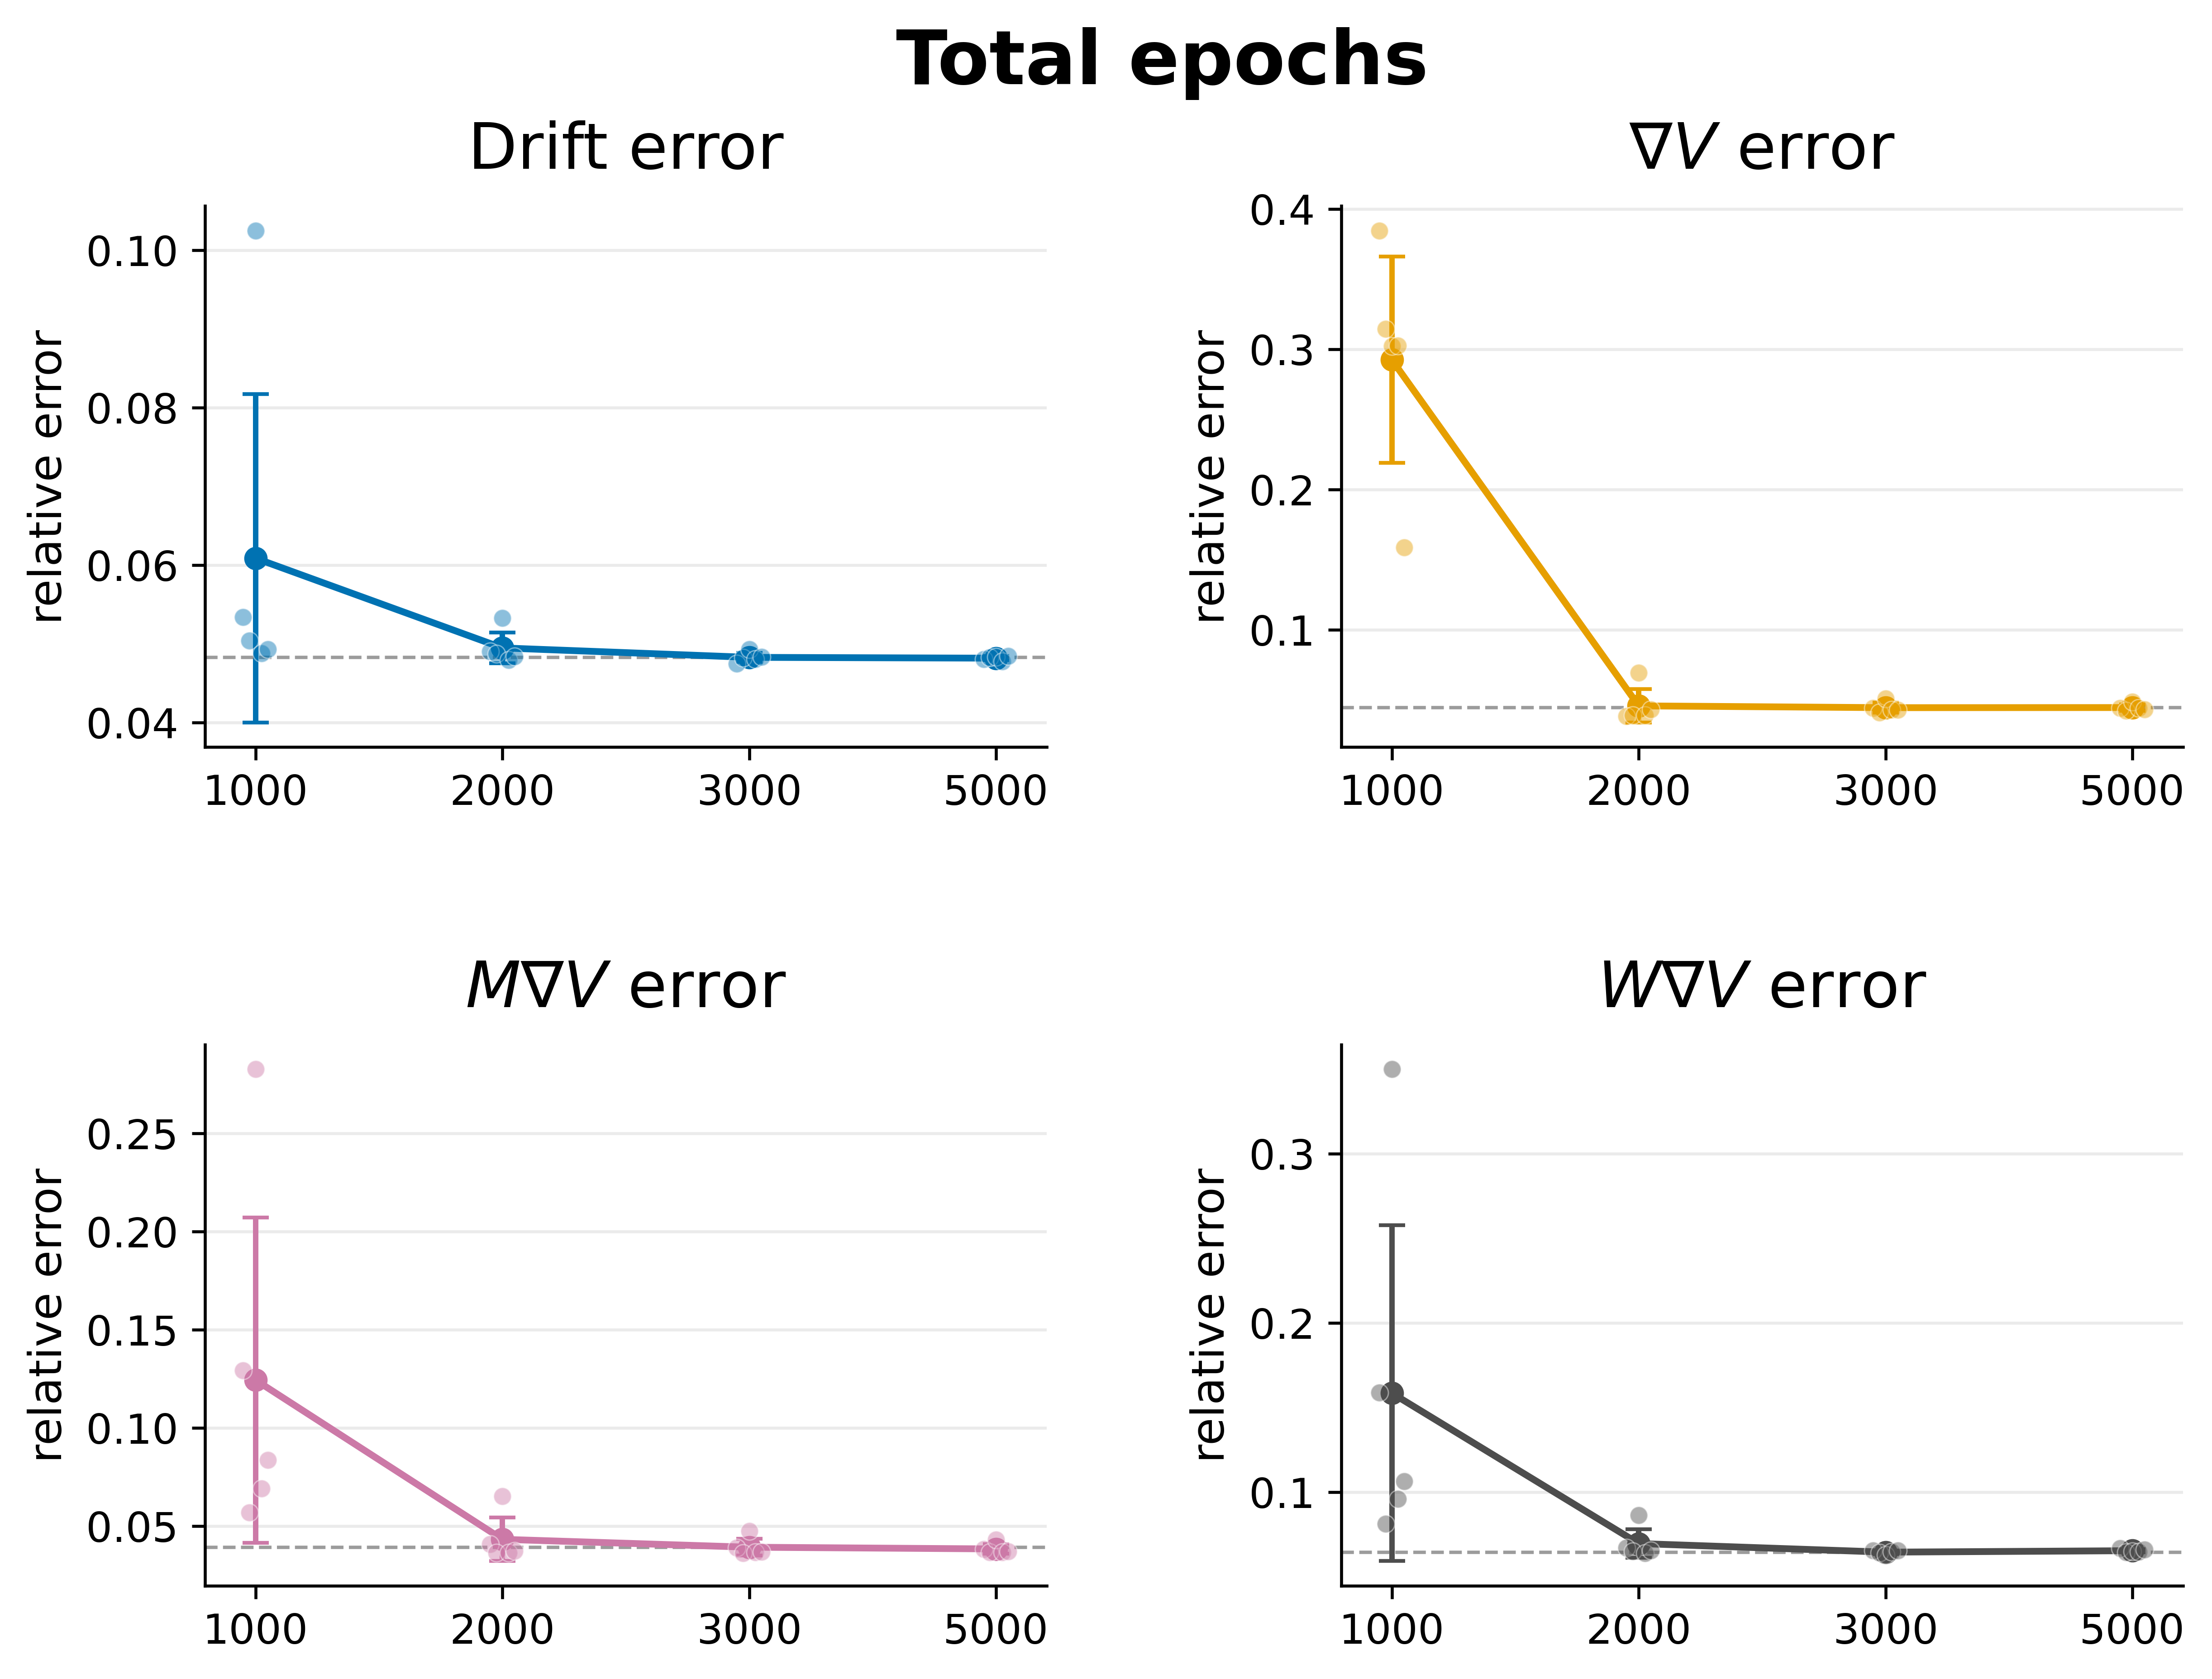

In [4]:
# 重新画四张主图。改完上面的 PLOT_STYLE / YLIMS / EXCLUDE_SEEDS 后，从这里重新运行即可。
figs = plot_all_factors(save=False)

saved: /mnt/nfs/homes/aiqing/UIDD-jax/examples/nonlinear_case/outputs/uidd_sensitivity/analysis/replots/network_metrics_replot.pdf


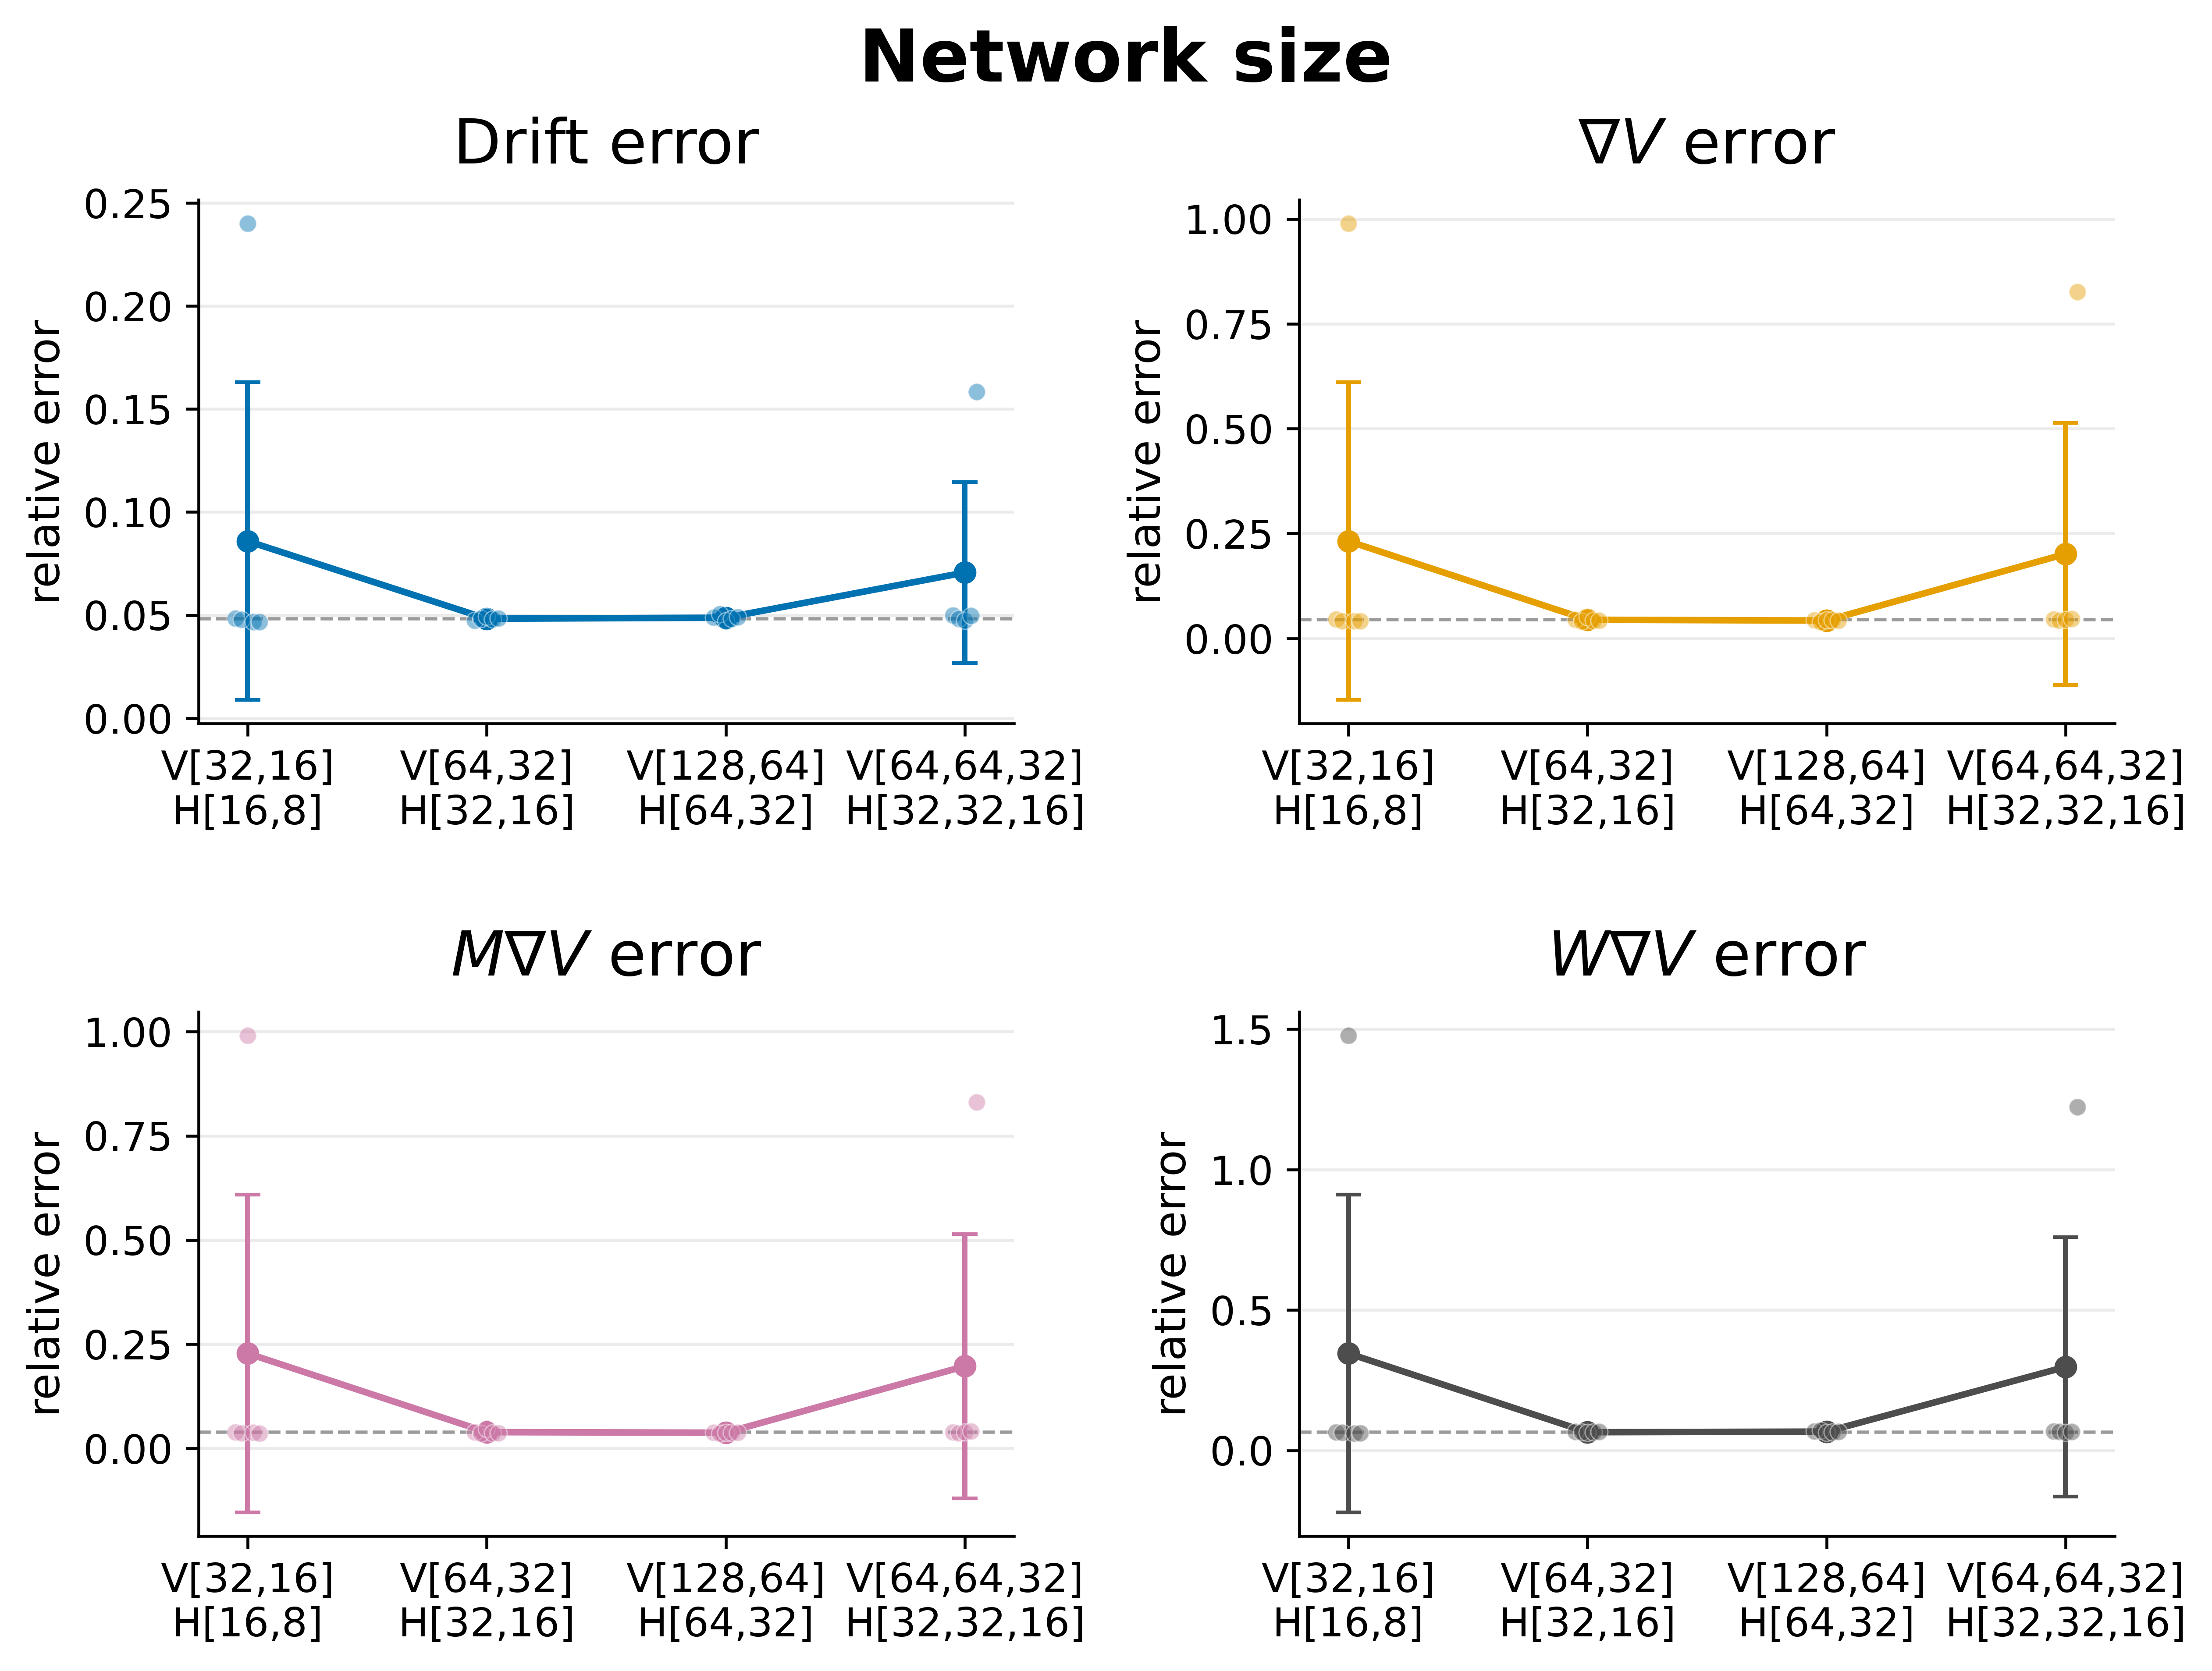

saved: /mnt/nfs/homes/aiqing/UIDD-jax/examples/nonlinear_case/outputs/uidd_sensitivity/analysis/replots/learning_rate_metrics_replot.pdf


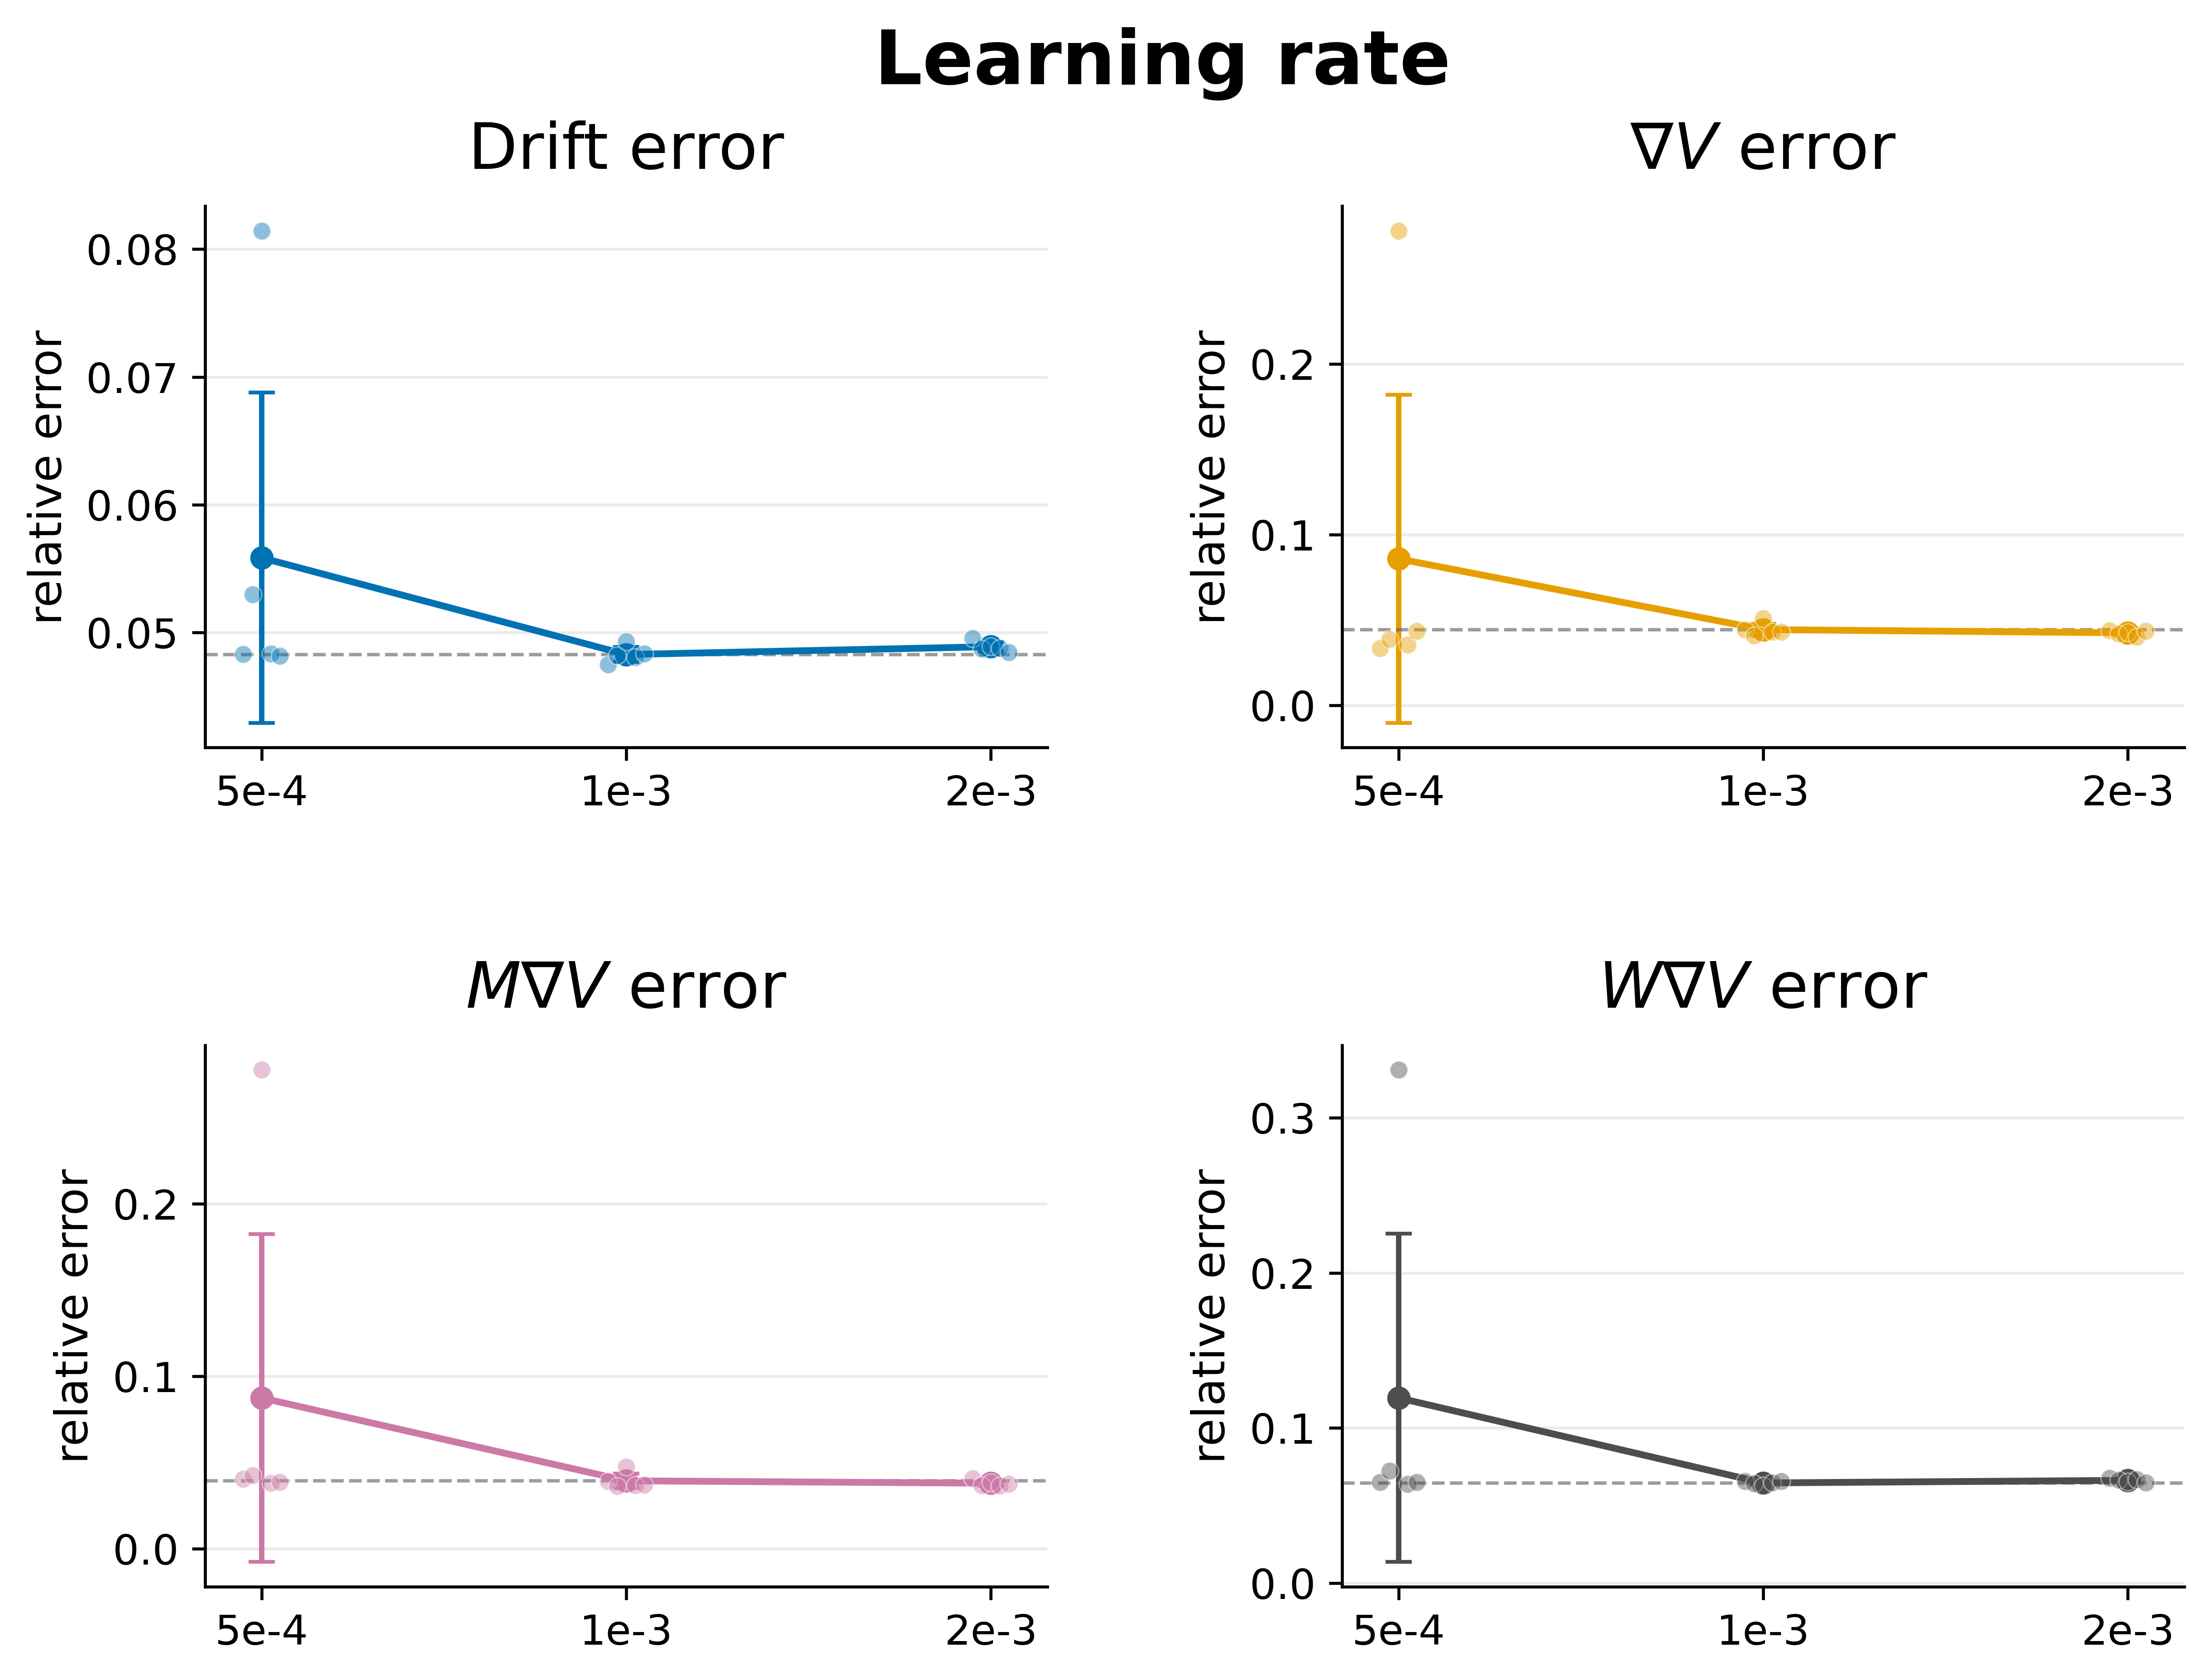

saved: /mnt/nfs/homes/aiqing/UIDD-jax/examples/nonlinear_case/outputs/uidd_sensitivity/analysis/replots/batch_size_metrics_replot.pdf


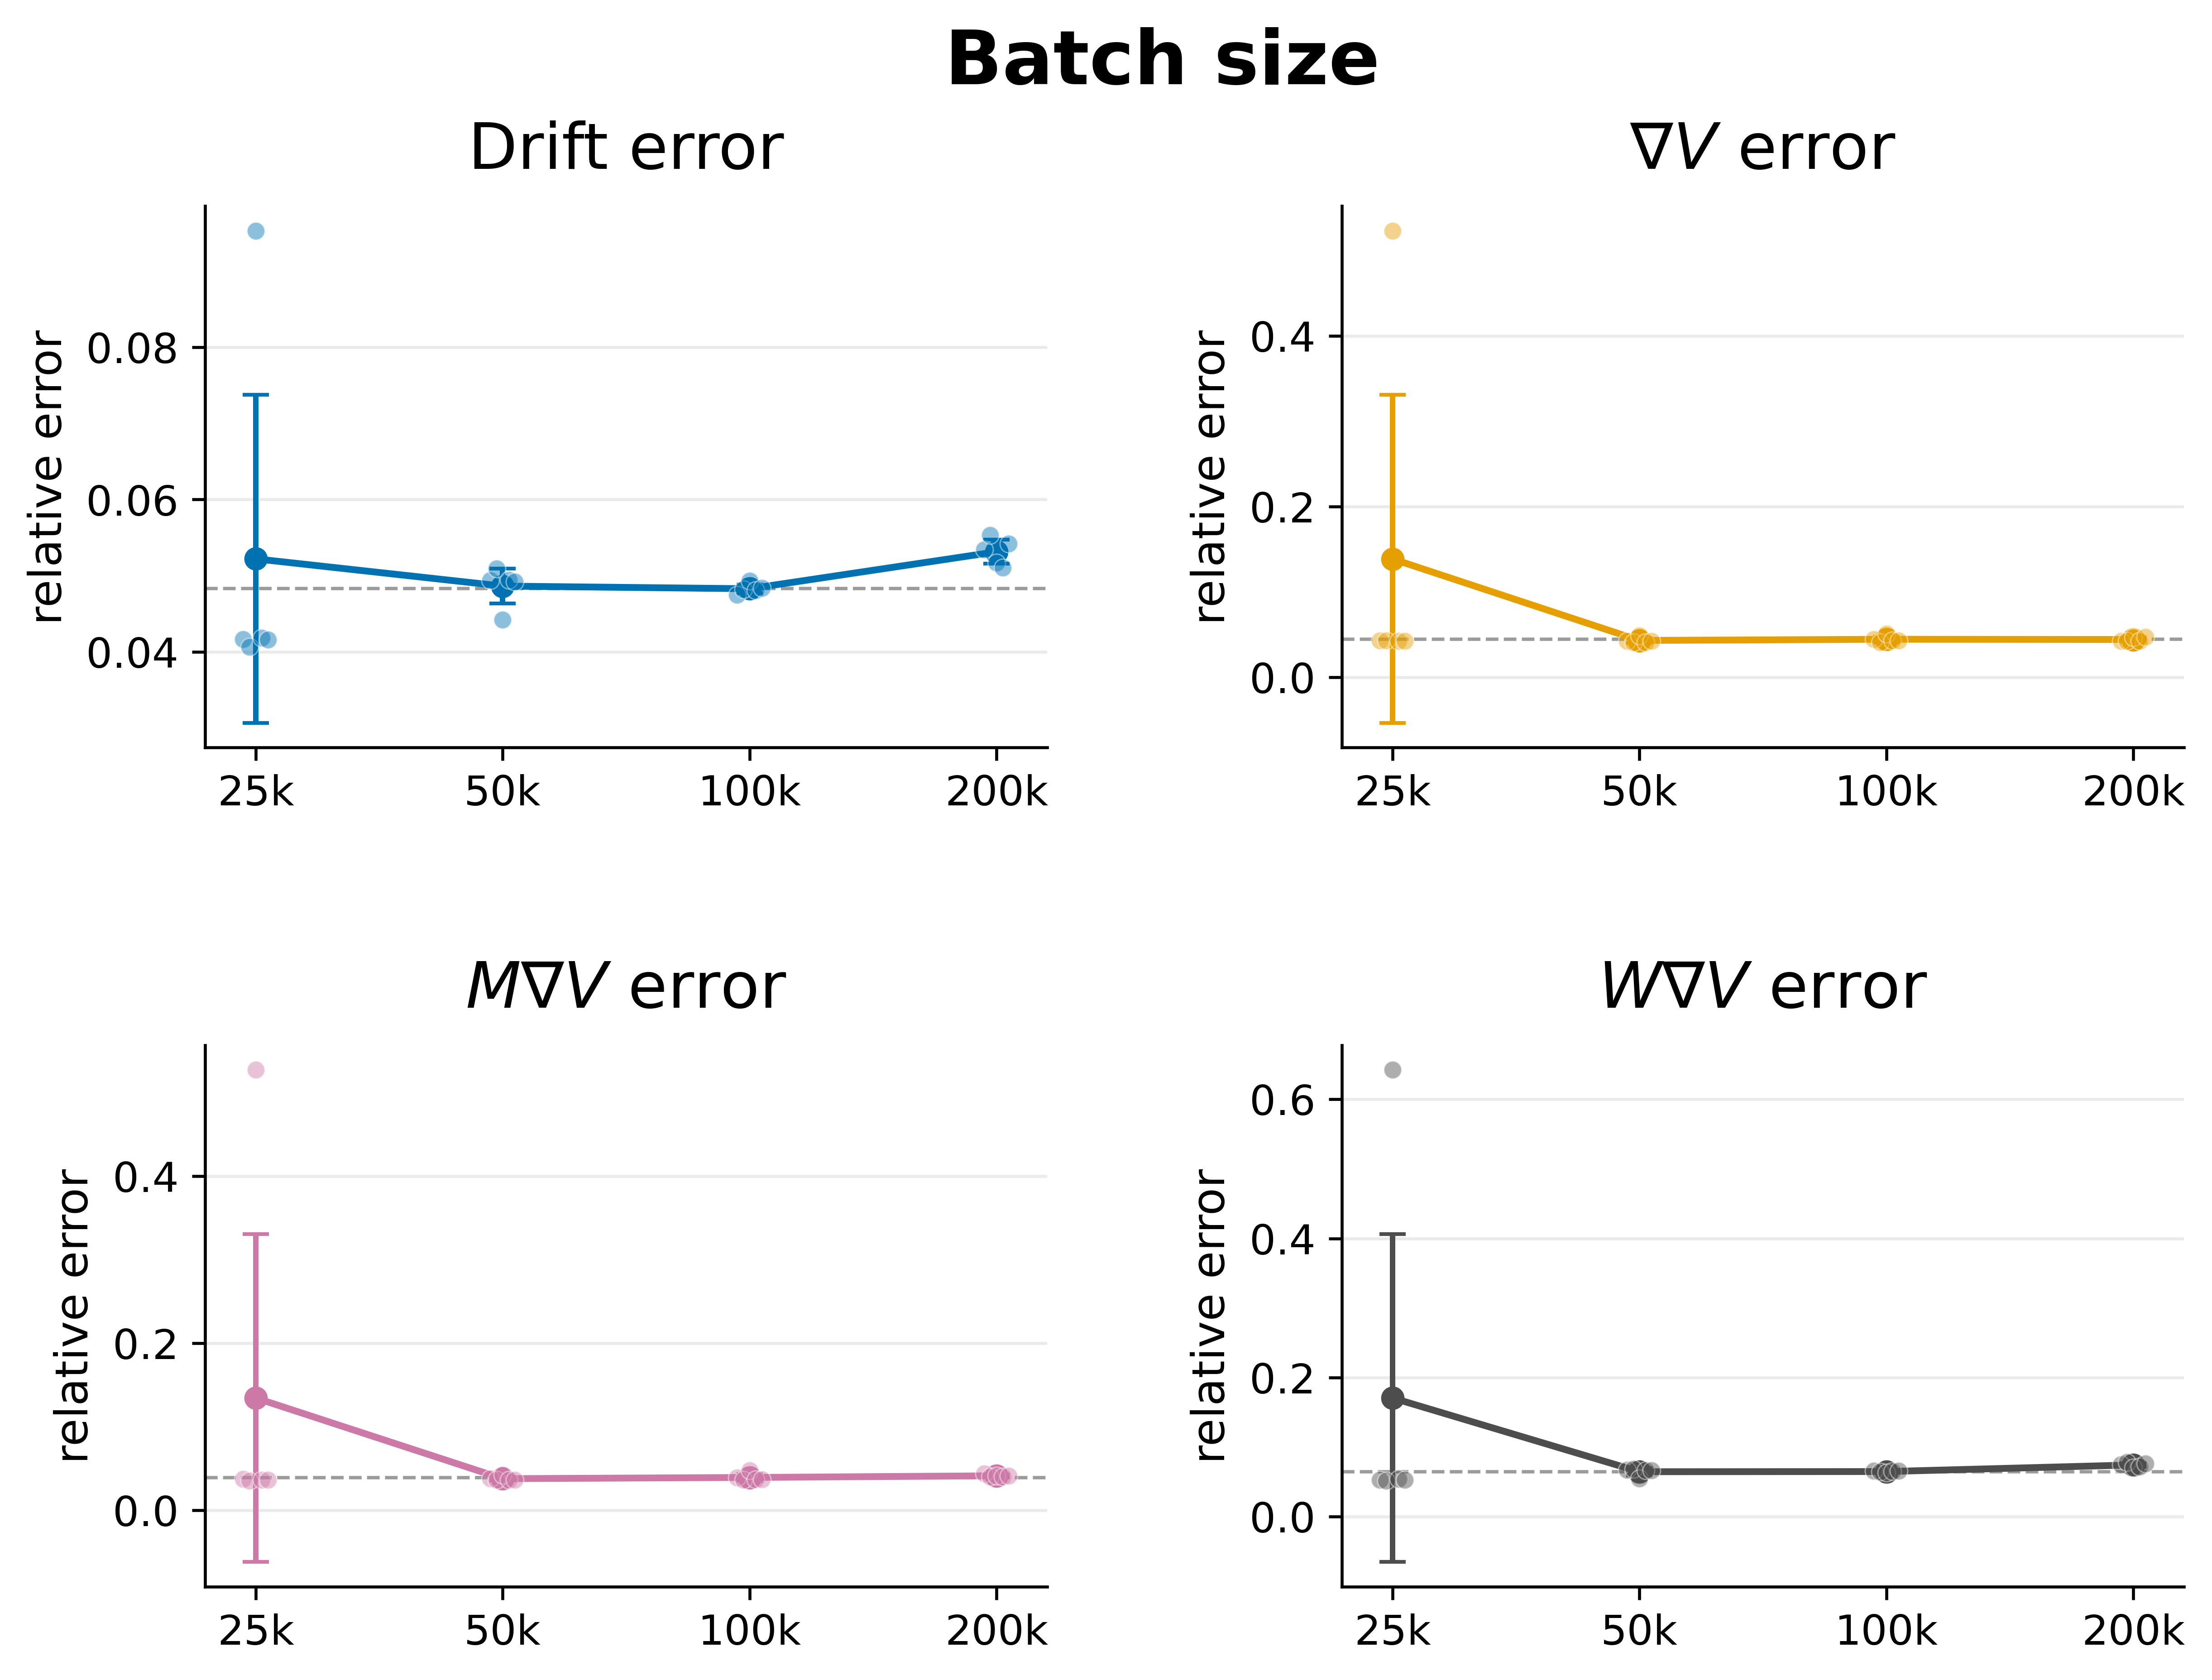

saved: /mnt/nfs/homes/aiqing/UIDD-jax/examples/nonlinear_case/outputs/uidd_sensitivity/analysis/replots/num_epochs_metrics_replot.pdf


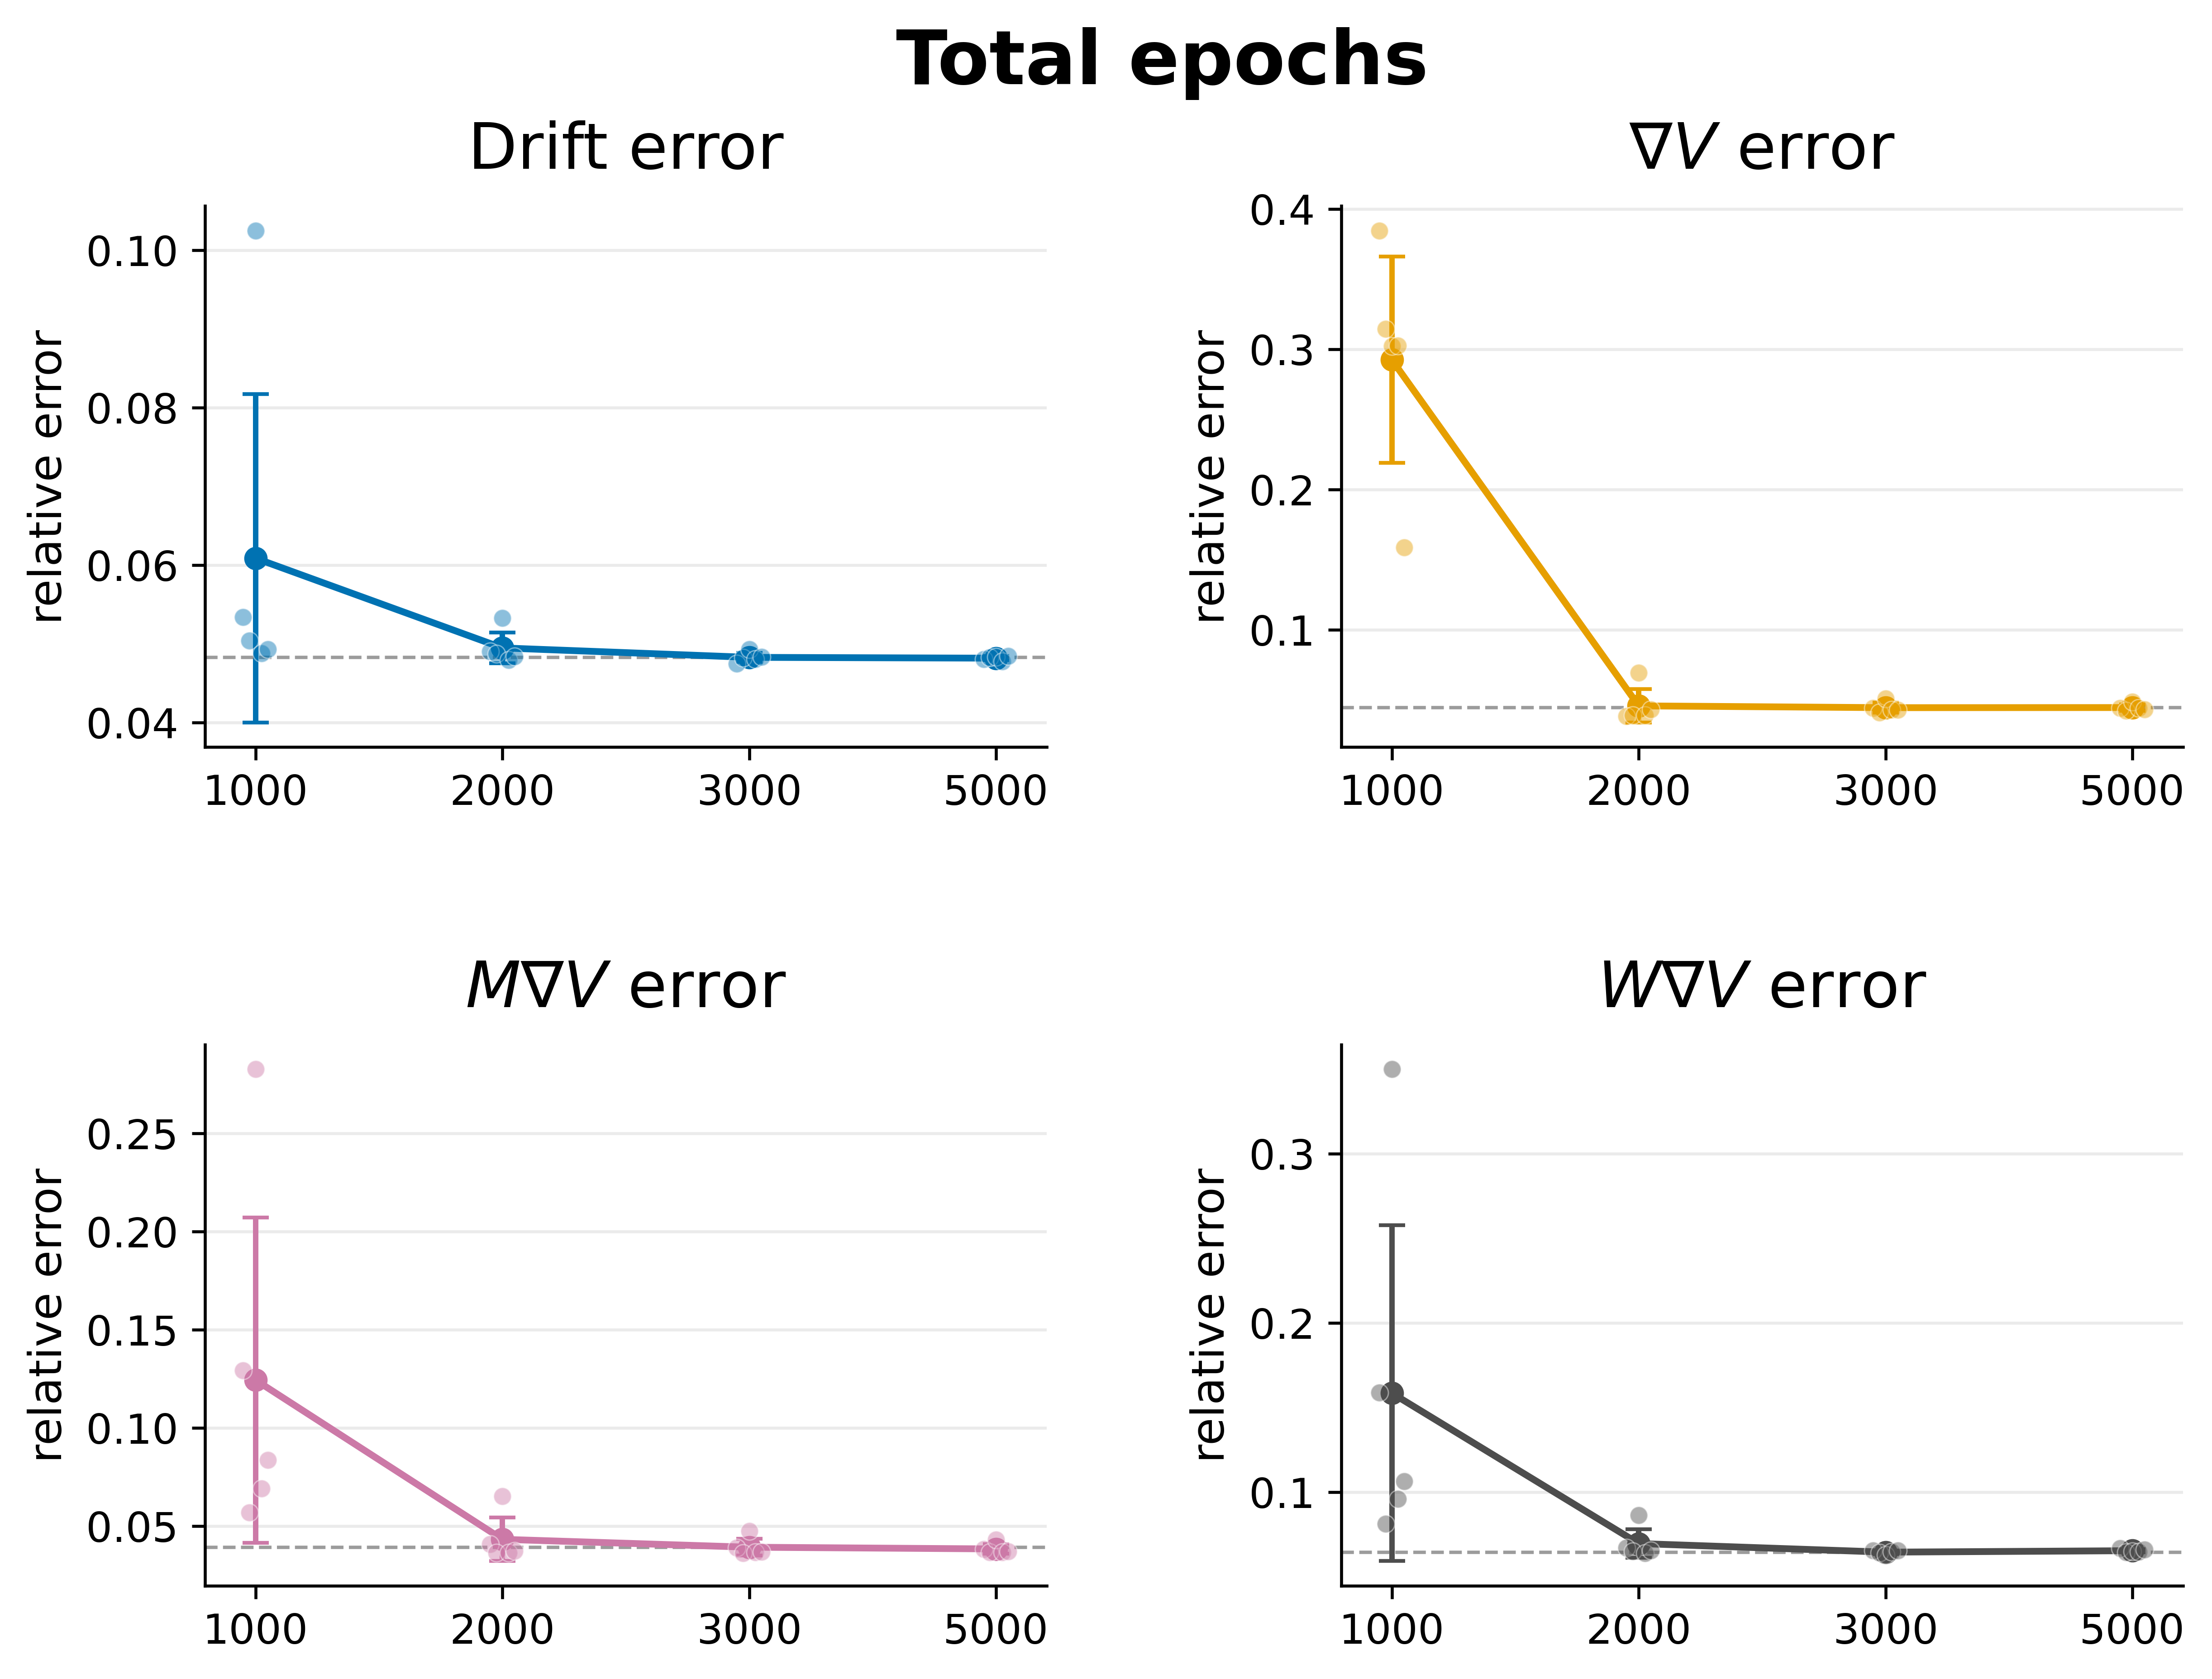

In [5]:
# 保存当前样式的图片。
# 会保存到 outputs/uidd_sensitivity/analysis/replots/
SAVE_FIGURES = True
if SAVE_FIGURES:
    figs = plot_all_factors(save=True)

## 单独微调某一张图

下面这个单元适合对单张图做精细调整，比如只改 `batch_size` 图的大小、y 轴范围、是否显示 seed 点。

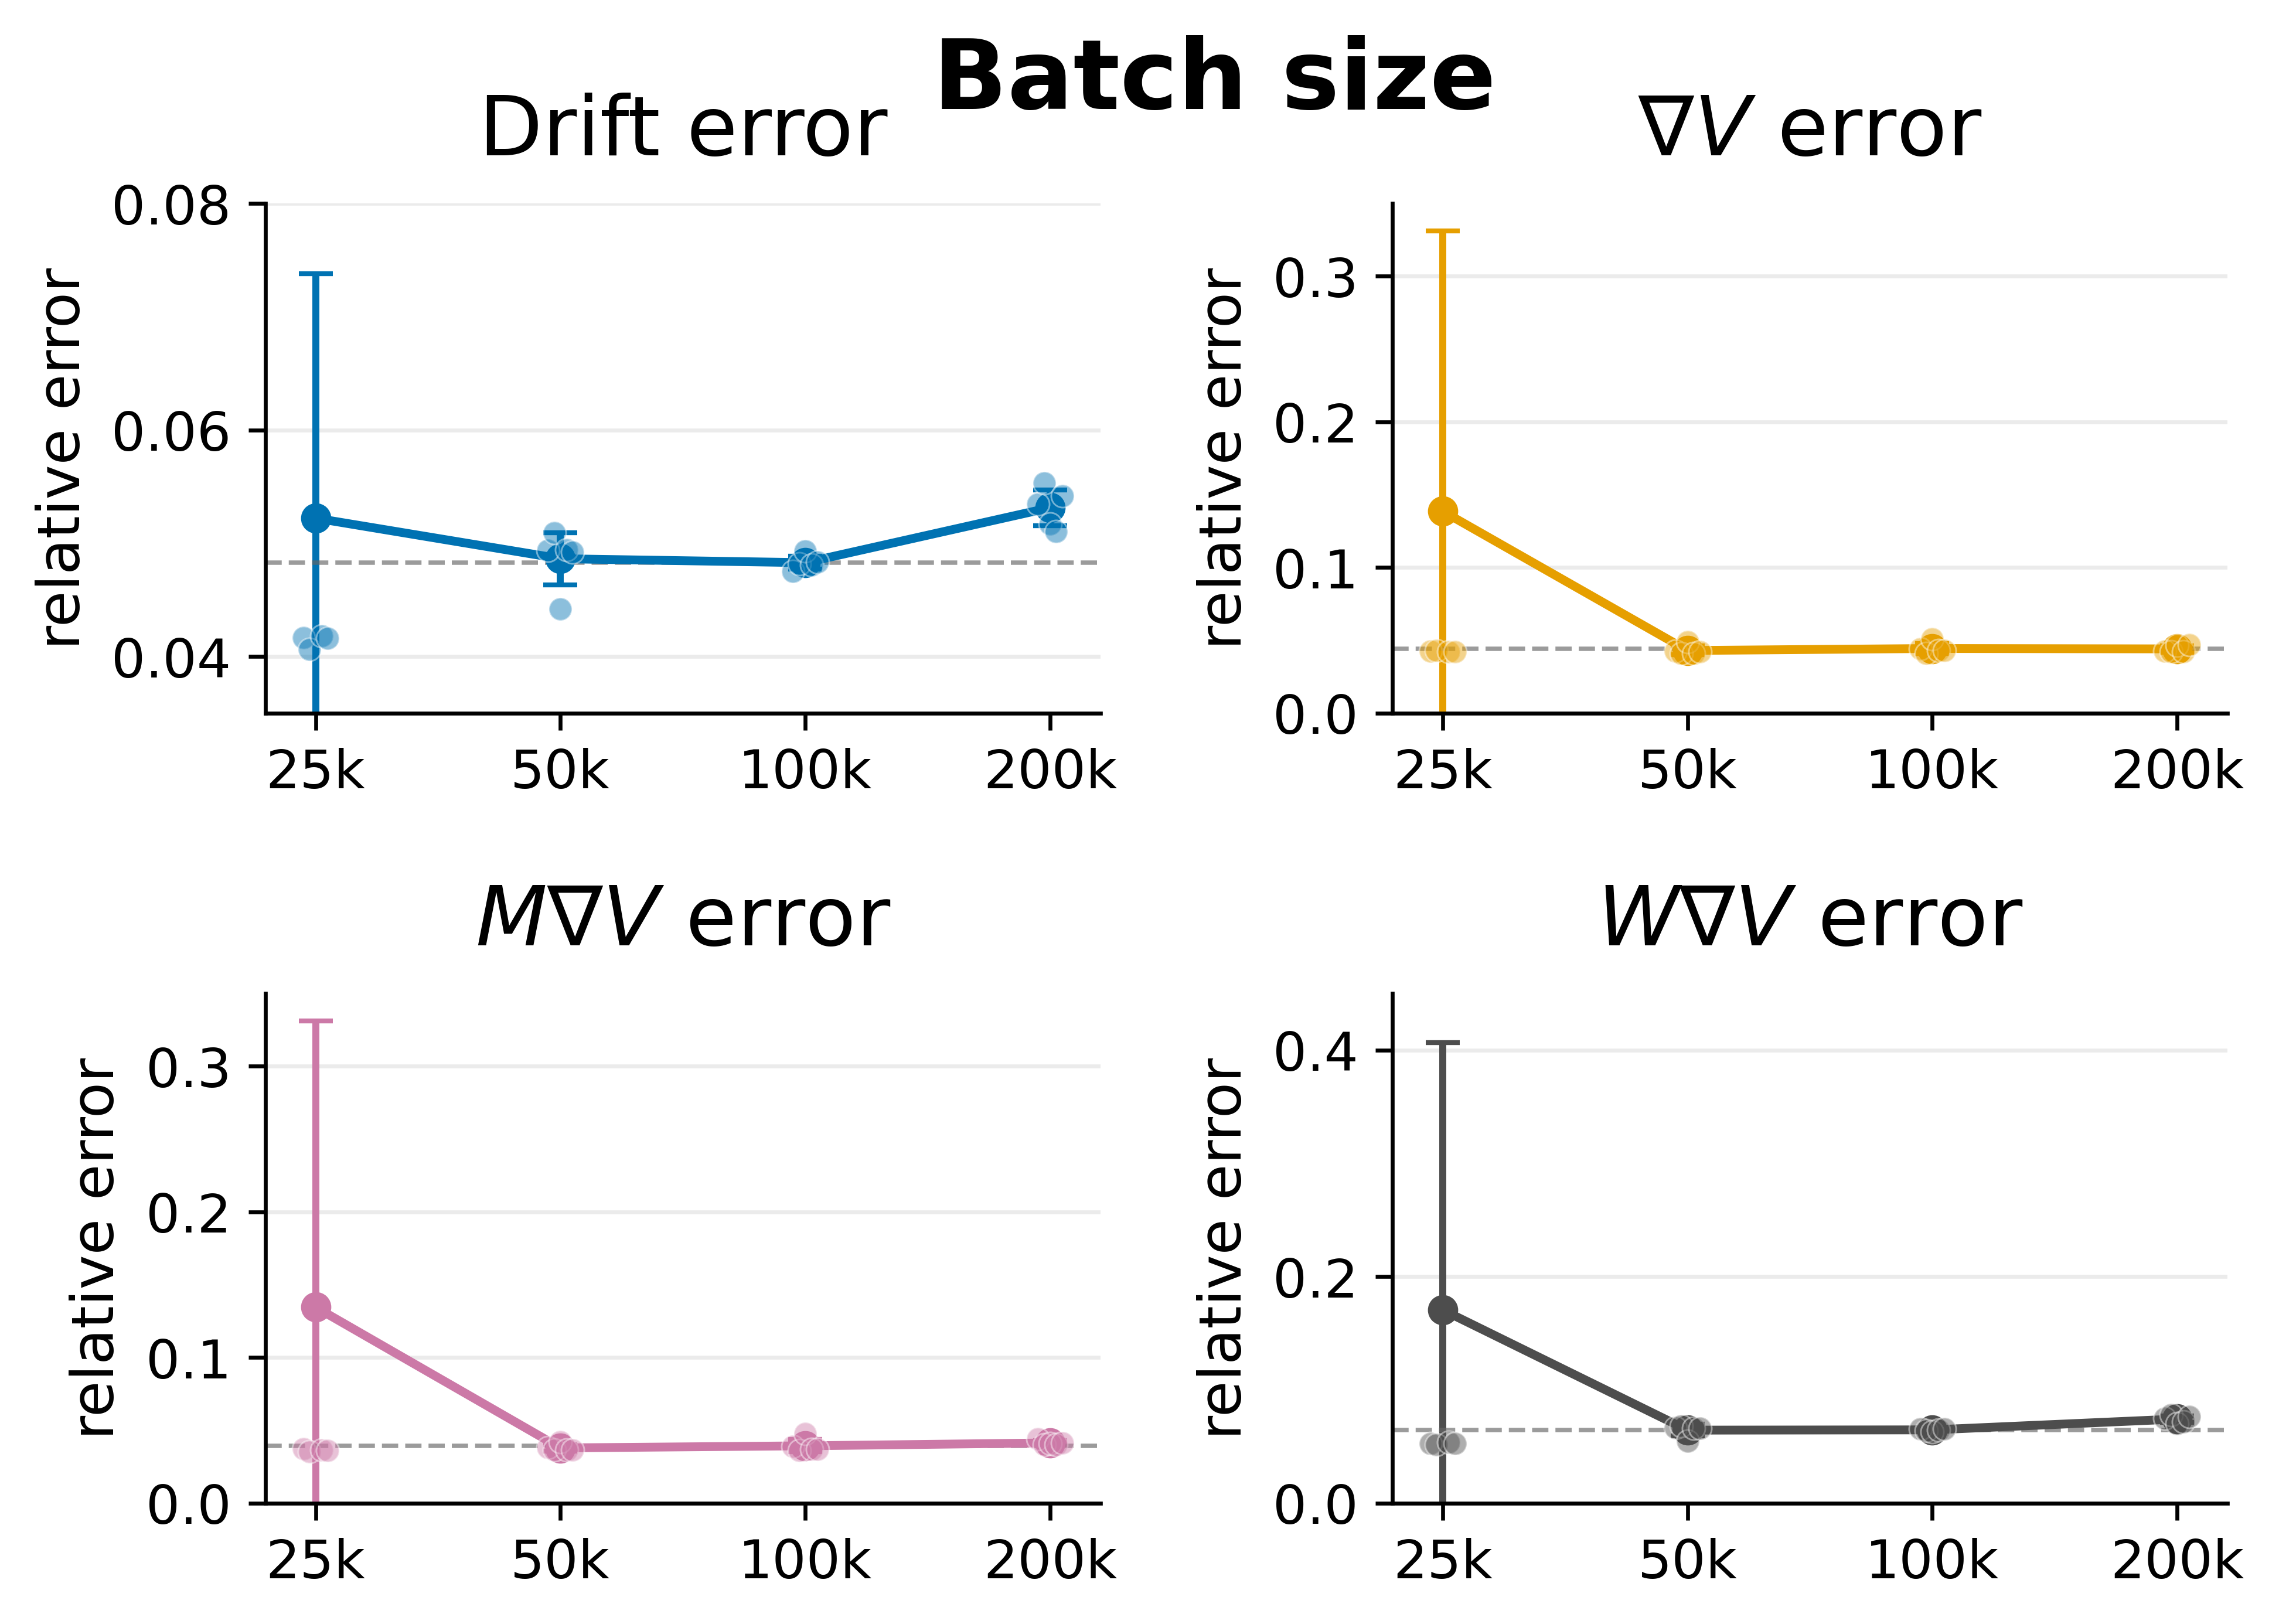

In [6]:
# 示例：单独重画 batch_size，并限制 gradV / MgradV / WgradV 的 y 轴范围。
custom_style = {
    "figsize": (7.2, 4.8),
    "show_seed_points": True,
    "show_errorbars": True,
    "x_rotation": 0,
}
custom_ylims = {
    "drift": (0.035, 0.08),
    "gradV": (0.0, 0.35),
    "MgradV": (0.0, 0.35),
    "WgradV": (0.0, 0.45),
}

fig, axes = plot_factor(
    "batch_size",
    style=custom_style,
    ylims=custom_ylims,
    save=False,
)
display(fig)
plt.close(fig)

## 对照表

如果要检查某个异常点，可以先看逐 seed 表。

In [7]:
display_cols = ["run_id", "factor", "level", "seed", "drift", "gradV", "MgradV", "WgradV", "last_train_loss", "last_test_loss"]
by_seed[display_cols].sort_values(["factor", "run_id", "seed"]).reset_index(drop=True)

,run_id,factor,level,seed,drift,gradV,MgradV,WgradV,last_train_loss,last_test_loss
0,baseline,baseline,3000,0,0.047484,0.044196,0.038930,0.065733,3.490692,3.485094
1,baseline,baseline,3000,1,0.048195,0.040937,0.036280,0.064233,3.491114,3.484817
2,baseline,baseline,3000,12,0.049302,0.050939,0.047572,0.062836,3.495333,3.493984
3,baseline,baseline,3000,123,0.048063,0.042862,0.036804,0.064703,3.490699,3.484721
4,baseline,baseline,3000,1234,0.048354,0.042850,0.037015,0.065719,3.490966,3.484537
...,...,...,...,...,...,...,...,...,...,...
60,epochs_5000,num_epochs,5000,0,0.048047,0.044072,0.038385,0.066837,3.490448,3.485175
61,epochs_5000,num_epochs,5000,1,0.048302,0.042248,0.036718,0.064446,3.490889,3.484769
62,epochs_5000,num_epochs,5000,12,0.048345,0.048752,0.043141,0.065126,3.493876,3.491719
63,epochs_5000,num_epochs,5000,123,0.047748,0.043969,0.036764,0.064844,3.490498,3.484840
